In [1]:
import os
import numpy as np
from pprint import pformat
import pandas as pd
import geopandas as gpd
import rasterio
import rioxarray as rxr
import xarray as xr
import matplotlib.pyplot as plt
from flopy.discretization import StructuredGrid, UnstructuredGrid
from shapely.geometry import LineString, MultiLineString, MultiPoint, MultiPolygon, Point, Polygon, box
from rasterio.transform import from_origin
from flopy.utils import GridIntersect
from rasterio.plot import show
from scipy.interpolate import griddata
from flopy.export.shapefile_utils import recarray2shp, shp2recarray
import flopy
from shapely.ops import unary_union
from flopy.utils import Raster, flopy_io
from flopy.utils.gridgen import Gridgen
from scipy.spatial import cKDTree
from rasterio.features import rasterize
from scipy.ndimage import uniform_filter
from pathlib import Path

gridgen_exe = flopy.which("gridgen")
if gridgen_exe is None:
    msg = (
        "Warning, gridgen is not in your path. "
        "When you create the griden object you will need to "
        "provide a full path to the gridgen binary executable."
    )
    print(msg)
else:
    print(f"gridgen executable was found at: {flopy_io.relpath_safe(gridgen_exe)}")

gridgen executable was found at: ..\..\..\..\..\AppData\Local\flopy\bin\gridgen.EXE


In [2]:

coastline = gpd.read_file('C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\coastline_yucatan.shp')
yucatan_raster = Raster.load("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\dem_yucatan2.tif") 
cenotesRing = gpd.read_file('C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\cenotesRing.shp')
df = pd.read_csv("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\piezometric_median_1996_2025_with_Weights.csv") # piezometric heads values
well_data = gpd.read_file("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\wells_yucatan.shp") ## water extraction data by municipality
south_boundary = gpd.read_file('C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\south_boundary.shp')
population_raster = Raster.load("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\population.tif") # population density raster
data= xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\netCDF\\data_stream-moda.nc", chunks={"time":24, "latitude":400, "longitude":400}) ## Climate data for evaporation package, NetCDF4 data file format
pressure_data = xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\pressure_data\\data_stream-moda_stepType-avgua.nc")
## load Yucatan polygon in geographic CRS (EPSG:4326)
yucatan = gpd.read_file("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\yucatan_state.shp") ## yucatan state polygon in CRS>4326
#yucatanRaster_remuestreado = np.load("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\yucatan_modelC\\quadtreeGrid\\yucatanRaster_remuestreado.npy")
yucatanRaster_unstructured = np.load("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\yucatan_modelC\\quadtreeGrid\\yucatanRaster_unstructured.npy")
yucatanRaster_structured = np.load("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\yucatan_modelC\\quadtreeGrid\\yucatanRaster_structured.npy")
yucatanRaster_domain = np.load("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\yucatan_modelC\\quadtreeGrid\\yucatanRaster_domain.npy")

C:\Users\sebas\AppData\Local\Temp\ipykernel_4712\834139978.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 400. This could degrade performance. Instead, consider rechunking after loading.
  data= xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\netCDF\\data_stream-moda.nc", chunks={"time":24, "latitude":400, "longitude":400}) ## Climate data for evaporation package, NetCDF4 data file format


In [3]:
# Create the flopy simulation object
modelname='quadtree_caseC'
sim = flopy.mf6.MFSimulation(sim_name=modelname, exe_name='mf6', version='mf6', sim_ws='.')

In [4]:
with rasterio.open("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\dem_yucatan2.tif") as src:
    print("CRS:", src.crs)
    print("Resolution:",src.res)
    print("Bounds: ", src.bounds)
    NODATA = src.nodata
    bounds = [src.bounds.left, src.bounds.bottom, src.bounds.right, src.bounds.top]

CRS: PROJCS["WGS 84 / UTM zone 16N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-87],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Resolution: (14.811454703952203, 14.811454696729117)
Bounds:  BoundingBox(left=142384.3855, bottom=2161902.4815, right=444819.4791, top=2395108.8357)


In [5]:
### WE GET THE DATA ELEVATION FROM THE RASTER YUCATAN FILE 
arr = yucatan_raster.get_array(1) #Elevation data of the raster yucatan file
idx = np.isfinite(arr)
vmin, vmax = arr[idx].min(), arr[idx].max()
#Minimum and maximum value of the band's raster file
vmin, vmax

(-16.0, 213.0)

In [6]:
## Creation of the modelgrid
rot = 0
nrow = 90
ncol = 90
nlay = 2
lx = int(bounds[2] - bounds[0])
ly = int(bounds[3] - bounds[1])
delr = np.ones((ncol,)) * (lx/ncol)
delc = np.ones((nrow,)) * (ly/nrow)


idomain = np.where(yucatanRaster_domain == NODATA,0,1)
idomain = np.stack([idomain, idomain], axis=0)

# parent structured grid: nlay=2, nrow, ncol
top = yucatanRaster_structured  # shape (nrow, ncol)
upland_mask = (top > 50.0) & (idomain[0]==1)
#upland_refinement = (yucatanRaster_structured > 50.0) & (yucatanRaster_structured != NODATA)

thk1 = 50.0                 # or your real thickness field for L1
thk2 = 200.0                 # or your real thickness for L2

botm1 = top - thk1
botm1[upland_mask] = top[upland_mask] - 300.0
botm2 = botm1 - thk2

botm = np.stack([botm1, botm2], axis=0)


#botm_parent = np.stack([botm1_parent, botm2_parent])  # shape (2, nrow, ncol)
# top = np.ones((nrow,nrow))
# botm1 = np.ones((nrow,nrow))
# botm2 = np.ones((nrow,nrow))


### THIS MODELGRID IS FOR CREATE THE NEXT USEFUL MODELGRID OF THE SIMULATION CASE A 
modelgrid = flopy.discretization.StructuredGrid(
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    botm=botm,
    angrot=0.0,
    top=top,
    delc=delc,
    nlay=nlay,
    xoff=bounds[0],
    yoff=bounds[1],
    #idomain=idomain,
    lenuni=2,
    crs=32616
)

In [7]:
# yucatanRaster_structured = yucatan_raster.resample_to_grid(modelgrid, band=yucatan_raster.bands[0], method='nearest', extrapolate_edges=True)
# np.save("yucatanRaster_structured.npy", yucatanRaster_structured)

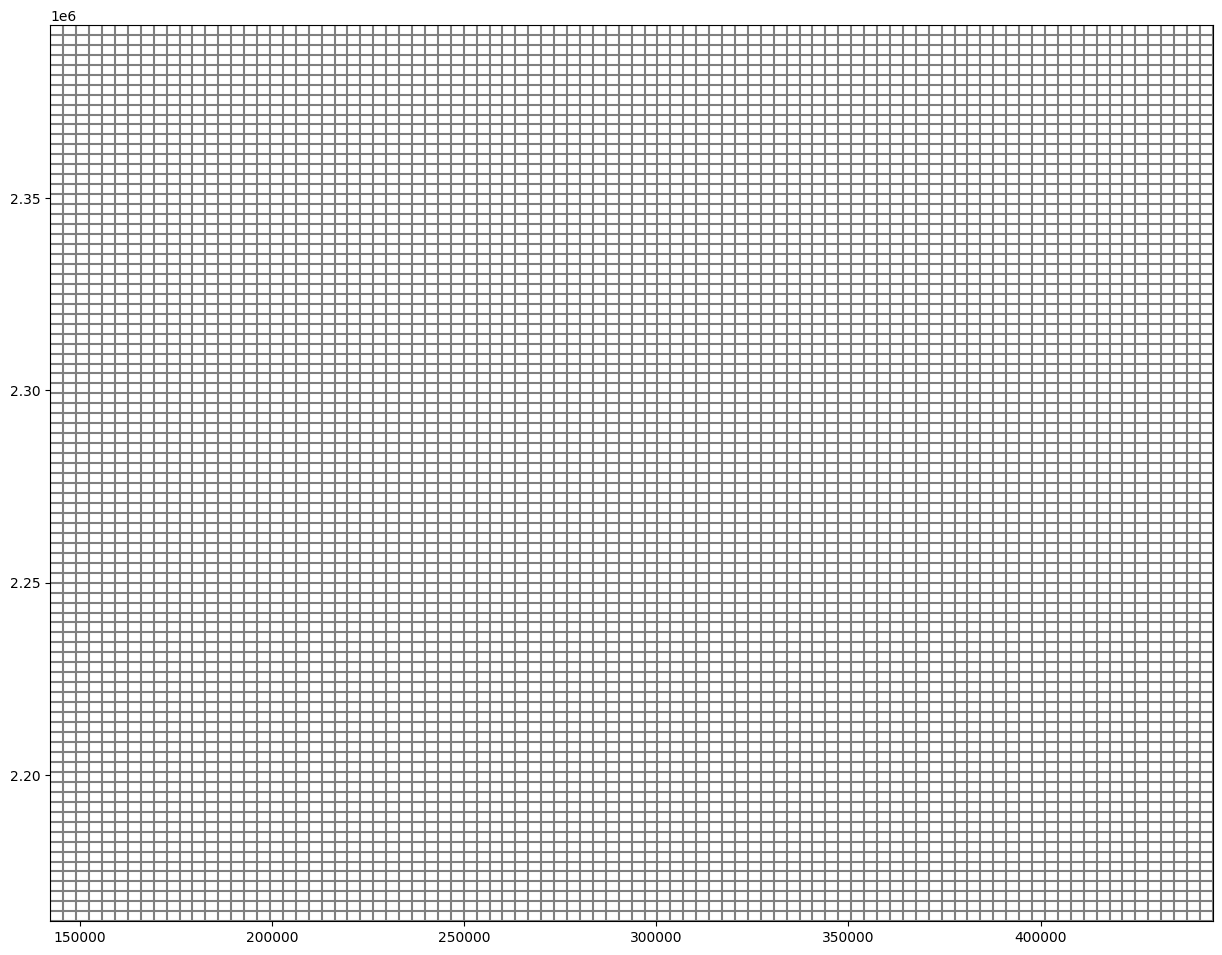

In [8]:
## PLOT OF THE ORIGINAL GRID

fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(1,1,1, aspect='equal')
mm = flopy.plot.PlotMapView(modelgrid=modelgrid)
mm.plot_grid()
#flopy.plot.plot_shapefile(yucatan, ax=ax, facecolor='r')
# flopy.plot.plot_shapefile(south_boundary, ax=ax, linewidth=10)

Text(0.5, 1.0, 'idomain -- Triangle modelgrid')

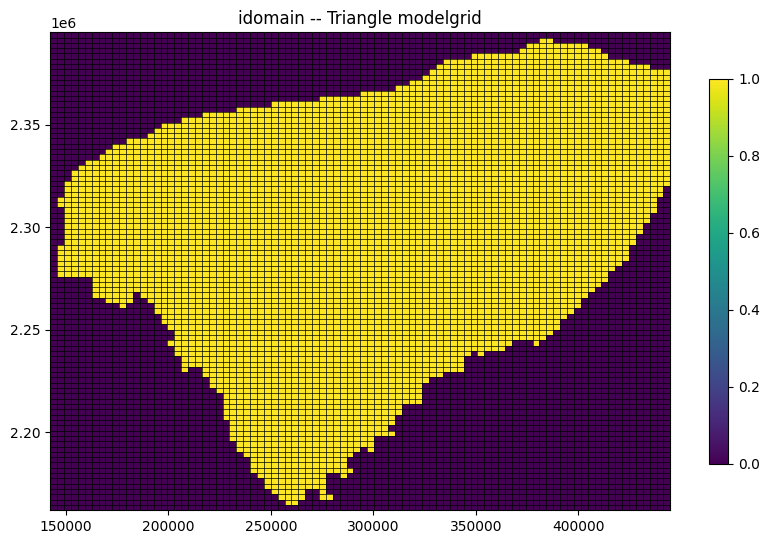

In [9]:

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1, aspect='equal')
pmv = flopy.plot.PlotMapView(modelgrid=modelgrid, ax=ax, layer=0)
pmv.plot_grid(ax=ax, lw=0.5, color='black')
raster = pmv.plot_array(idomain[0])
#elevation = pmv.plot_array(yucatanRaster_structured,
                            #masked_values=yucatan_raster.nodatavals)
#plt.colorbar(elevation, shrink=0.5)
plt.colorbar(raster, shrink=0.5)
plt.title('idomain -- Triangle modelgrid')

Text(0.5, 1.0, 'Elevation -- Triangle modelgrid')

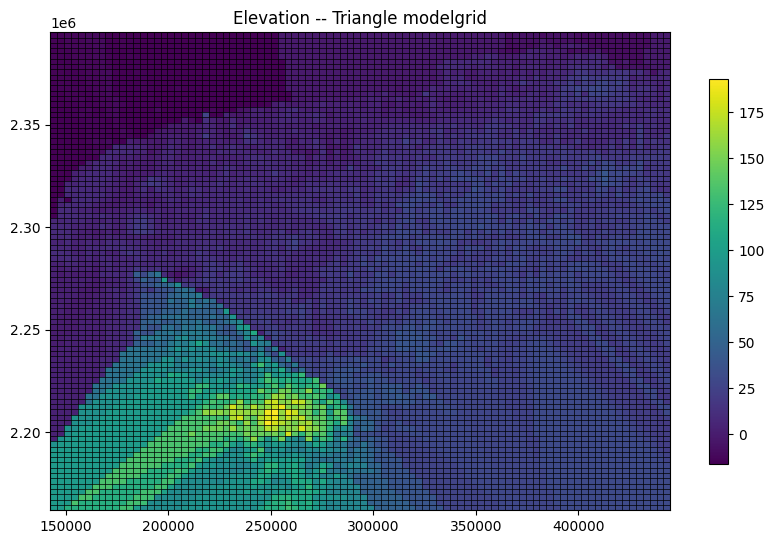

In [10]:


fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1, aspect='equal')
pmv = flopy.plot.PlotMapView(modelgrid=modelgrid, ax=ax, layer=0)
pmv.plot_grid(ax=ax, lw=0.5, color='black')
#raster = pmv.plot_array(upland_refinement)
elevation = pmv.plot_array(top,
                            masked_values=yucatan_raster.nodatavals)
plt.colorbar(elevation, shrink=0.5)
#plt.colorbar(raster, shrink=0.5)
plt.title('Elevation -- Triangle modelgrid')

Text(0.5, 1.0, 'Elevation -- Triangle modelgrid')

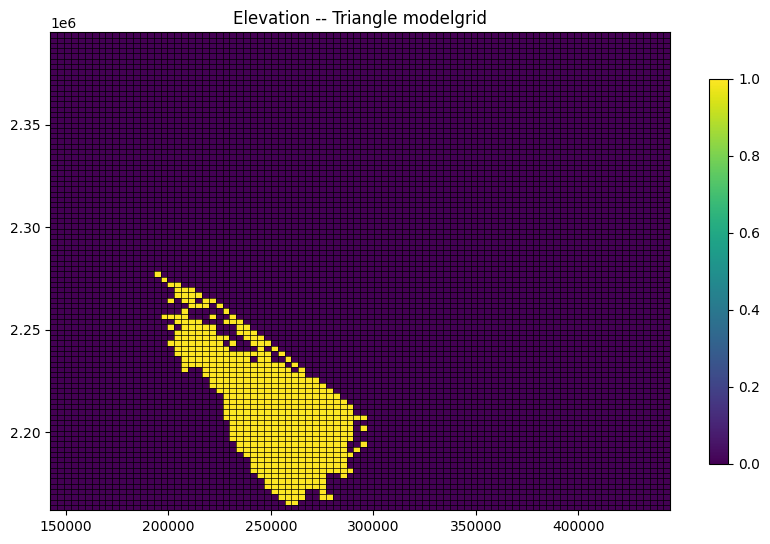

In [11]:

#upland_refinement = (yucatanRaster_structured > 50.0) & (yucatanRaster_structured != NODATA)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1, aspect='equal')
pmv = flopy.plot.PlotMapView(modelgrid=modelgrid, ax=ax, layer=0)
pmv.plot_grid(ax=ax, lw=0.5, color='black')
raster = pmv.plot_array(upland_mask)
#elevation = pmv.plot_array(yucatanRaster_triangle)
                            #masked_values=yucatan_raster.nodatavals)
#plt.colorbar(elevation, shrink=0.5)
plt.colorbar(raster, shrink=0.5)
plt.title('Elevation -- Triangle modelgrid')

In [12]:
refine_ids = np.where(upland_mask.ravel())[0]
geoms = []

for icell in refine_ids:
    verts = modelgrid.get_cell_vertices([int(icell)])
    geoms.append(Polygon(verts))

ref_union = unary_union(geoms)

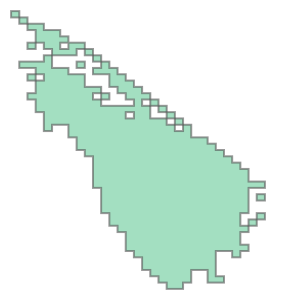

In [13]:
ref_union

In [14]:
type(ref_union)

shapely.geometry.multipolygon.MultiPolygon

In [15]:
poly_raw = yucatan.geometry[0]
poly_yucatan = poly_raw.simplify(50.0, preserve_topology=True)
pol_x, pol_y = poly_yucatan.representative_point().coords[0]

if ref_union.geom_type == "Polygon":
    ref_poly = ref_union
else:
    ref_poly = max(ref_union.geoms, key=lambda p:p.area)

#clean topology
ref_poly = ref_poly.buffer(-100)

# ##shrunken version of the outer polygon
# ##Distance in meters
#outer_inner = poly_yucatan.buffer(-100)

# # #clip refinement polygion to the inner domain
#ref_poly = ref_poly.intersection(outer_inner)
# ref_poly = ref_poly.buffer(0)

# if isinstance(ref_poly, MultiPolygon):
#     polys = list(ref_poly.geoms)  # each is a Polygon
# elif ref_poly.geom_type == "Polygon":
#     polys = [ref_poly]
# else:
#     raise ValueError("ref_poly must be Polygon or MultiPolygon")

# main_poly = max(polys, key=lambda p: p.area)
reg_x, reg_y = ref_poly.representative_point().coords[0]

In [16]:
type(ref_poly)

shapely.geometry.polygon.Polygon

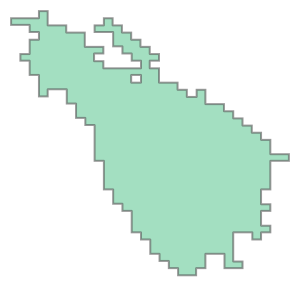

In [17]:
ref_poly

Region point inside Yucatan? True
Region points inside ref_poly? True


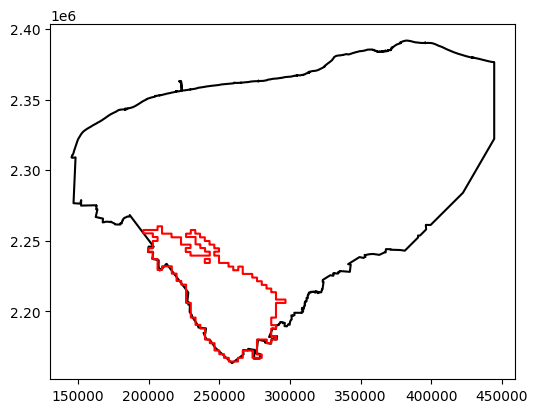

In [18]:
## 1) Check where the region points actually lies
print("Region point inside Yucatan?", poly_yucatan.contains(Point(pol_x, pol_y)))
print("Region points inside ref_poly?", ref_poly.contains(Point(reg_x, reg_y)))

## 2) Plot outer vs refinement poly
fig, ax = plt.subplots(figsize=(6,6))
gpd.GeoSeries(poly_yucatan).boundary.plot(ax=ax, color='k')
gpd.GeoSeries(ref_poly).boundary.plot(ax=ax, color='red')
ax.set_aspect("equal")
plt.show()

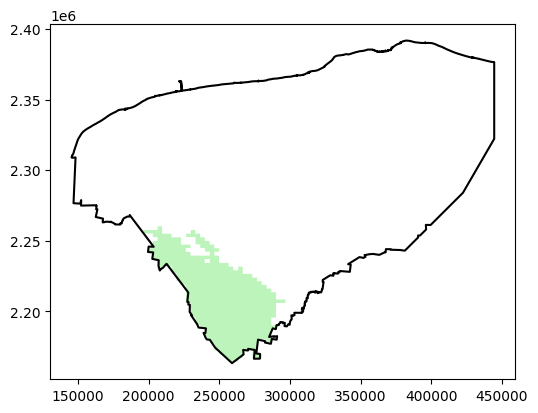

In [19]:
fig, ax = plt.subplots(figsize=(6,6))
gpd.GeoSeries(poly_yucatan).boundary.plot(ax=ax, color='k')
gpd.GeoSeries(ref_poly).plot(ax=ax, color='lightgreen', alpha=0.6)
ax.set_aspect("equal")
plt.show()

In [20]:
coast_buf = coastline.buffer(1500.0)
coast_u = coast_buf.union_all()
#coast_poly = coast_u.buffer(0)

if isinstance(coast_u, MultiPolygon):
    polys = list(coast_u.geoms)  # each is a Polygon
elif coast_u.geom_type == "Polygon":
    polys = [coast_u]
else:
    raise ValueError("coast_u must be Polygon or MultiPolygon")

coast_poly = max(polys, key=lambda p: p.area)

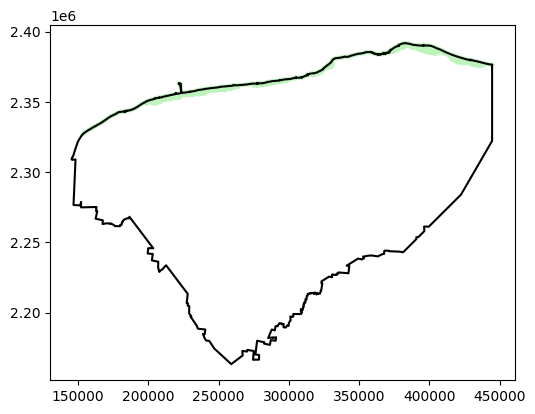

In [21]:
fig, ax = plt.subplots(figsize=(6,6))
gpd.GeoSeries(poly_yucatan).boundary.plot(ax=ax, color='k')
gpd.GeoSeries(coast_poly).plot(ax=ax, color='lightgreen', alpha=0.6)
ax.set_aspect("equal")
plt.show()

In [22]:
## CREATE AND BUILD THE GRIDGEN OBJECT MODEL WITH REFINED AREA ALONG THE CENOTES RING

g = Gridgen(modelgrid, model_ws='.')

g.add_active_domain("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\yucatan_state.shp", range(nlay))

## Upland zone
g.add_refinement_features([ref_poly], "Polygon", 1, layers=[0])
g.add_refinement_features([ref_poly], "Polygon", 3, layers=[1])

# coast zone
g.add_refinement_features([coast_poly], "Polygon", 1, layers=[0])
g.add_refinement_features([coast_poly], "Polygon", 3, layers=[1])

## BUILD THE GRIDGEN
g.build()

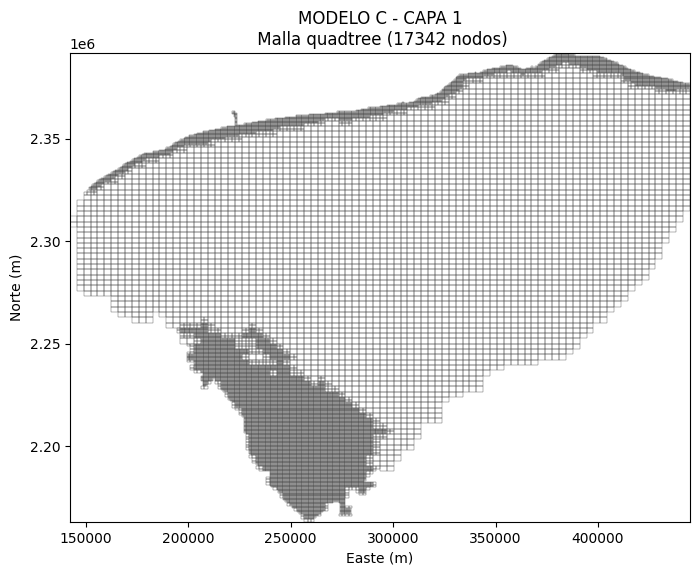

In [23]:
## PLOTTING OF THE NEW GRID (REFINED GRID)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(1,1,1, aspect='equal')
g.plot(ax, layer=0, linewidth=0.3, edgecolor='0.3')
plt.title('MODELO C - CAPA 1\n Malla quadtree (17342 nodos)')
plt.xlabel('Easte (m)')
plt.ylabel('Norte (m)')
plt.show()

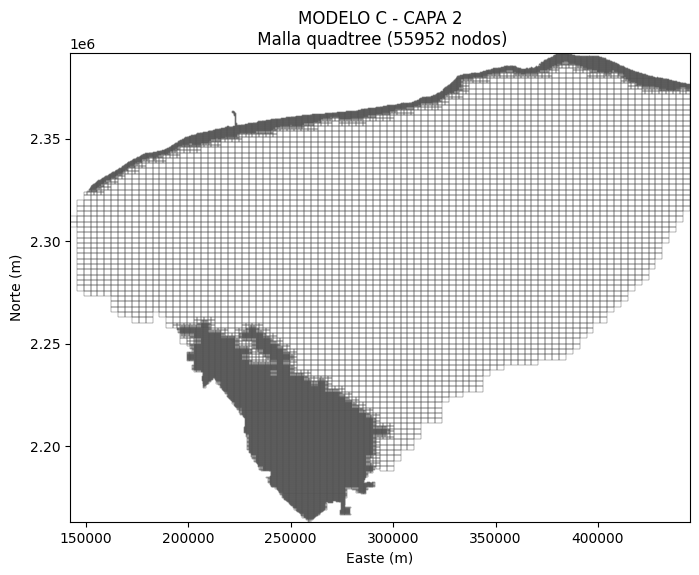

In [24]:
## PLOTTING OF THE NEW GRID (REFINED GRID)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(1,1,1, aspect='equal')
g.plot(ax, layer=1, linewidth=0.3, edgecolor='0.3')
plt.title('MODELO C - CAPA 2\n Malla quadtree (55952 nodos)')
plt.xlabel('Easte (m)')
plt.ylabel('Norte (m)')
plt.show()

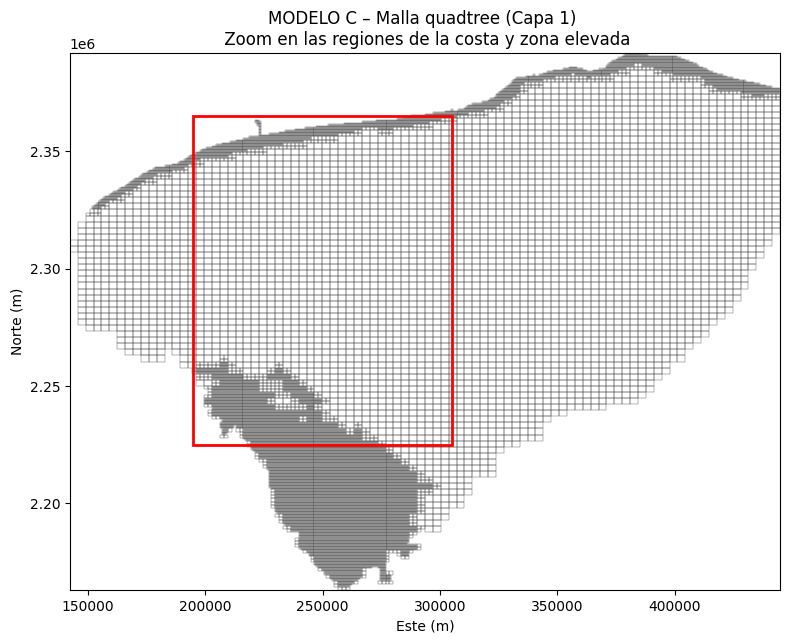

In [25]:
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(8, 8))

# plot grid
g.plot(ax=ax, layer=0, edgecolor="0.3", linewidth=0.3)

ax.set_title("MODELO C – Malla quadtree (Capa 1) \n Zoom en las regiones de la costa y zona elevada")
ax.set_xlabel("Este (m)")
ax.set_ylabel("Norte (m)")
ax.set_aspect("equal")

# zoom box limits
xmin, ymin, xmax, ymax = 200000, 2.23e6, 300000, 2.36e6
pad = 5000

x0 = xmin - pad
y0 = ymin - pad
width  = (xmax - xmin) + 2 * pad
height = (ymax - ymin) + 2 * pad

# create a NEW rectangle and add it ONCE
rect = Rectangle(
    (x0, y0),
    width,
    height,
    linewidth=2.0,
    edgecolor="red",
    facecolor="none",
    linestyle="-"
)

ax.add_patch(rect)

plt.tight_layout()
plt.show()



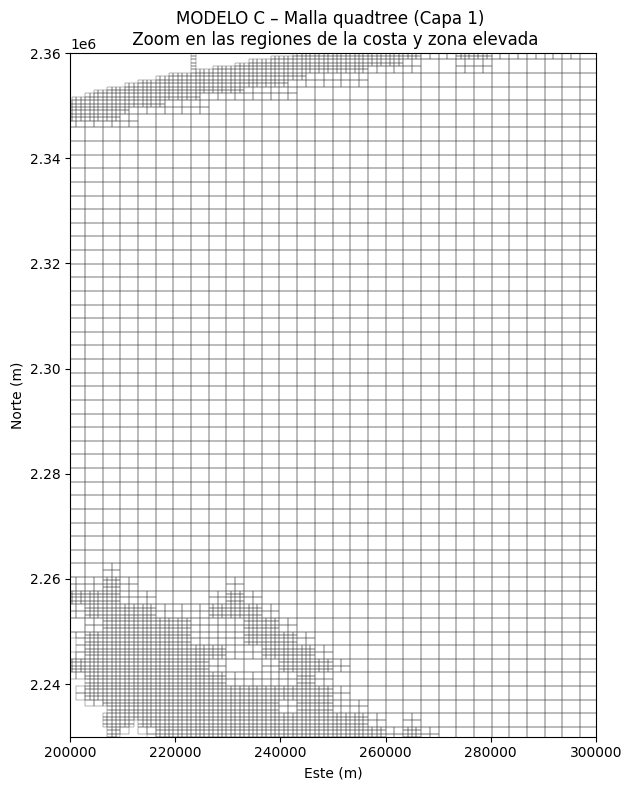

In [26]:
fig, ax = plt.subplots(figsize=(8, 8))

# --- your existing grid plot command here ---
# e.g., qtg.plot(ax=ax) or pc = PatchCollection(...); ax.add_collection(pc)
g.plot(ax=ax, layer=0, edgecolor='0.3', linewidth=0.3)

ax.set_title("MODELO C – Malla quadtree (Capa 1) \n Zoom en las regiones de la costa y zona elevada")
ax.set_xlabel("Este (m)")
ax.set_ylabel("Norte (m)")

# Replace these with the bounding box of the cenote ring in your coordinates:
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_aspect("equal")
plt.tight_layout()
plt.show()


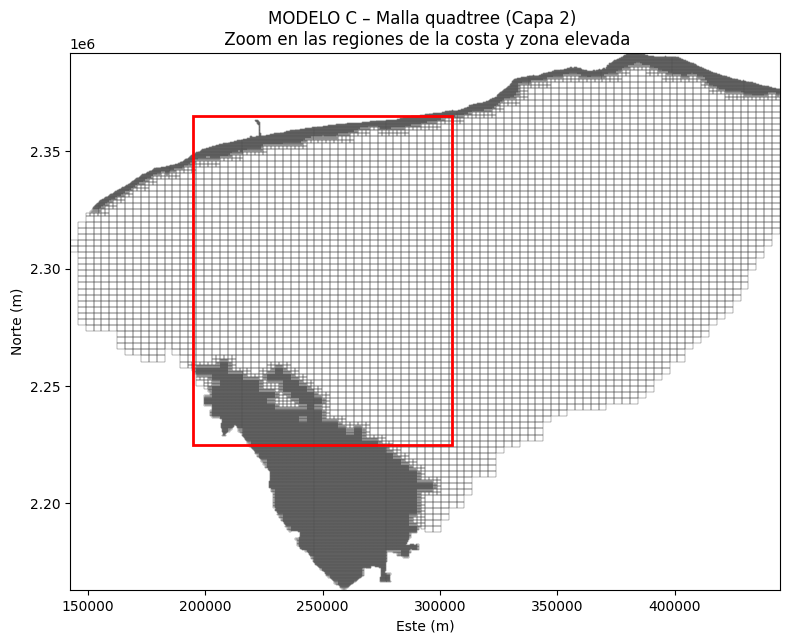

In [27]:

fig, ax = plt.subplots(figsize=(8, 8))

# plot grid
g.plot(ax=ax, layer=1, edgecolor="0.3", linewidth=0.3)

ax.set_title("MODELO C – Malla quadtree (Capa 2) \n Zoom en las regiones de la costa y zona elevada")
ax.set_xlabel("Este (m)")
ax.set_ylabel("Norte (m)")
ax.set_aspect("equal")

# zoom box limits
xmin, ymin, xmax, ymax = 200000, 2.23e6, 300000, 2.36e6
pad = 5000

x0 = xmin - pad
y0 = ymin - pad
width  = (xmax - xmin) + 2 * pad
height = (ymax - ymin) + 2 * pad

# create a NEW rectangle and add it ONCE
rect = Rectangle(
    (x0, y0),
    width,
    height,
    linewidth=2.0,
    edgecolor="red",
    facecolor="none",
    linestyle="-"
)

ax.add_patch(rect)

plt.tight_layout()
plt.show()



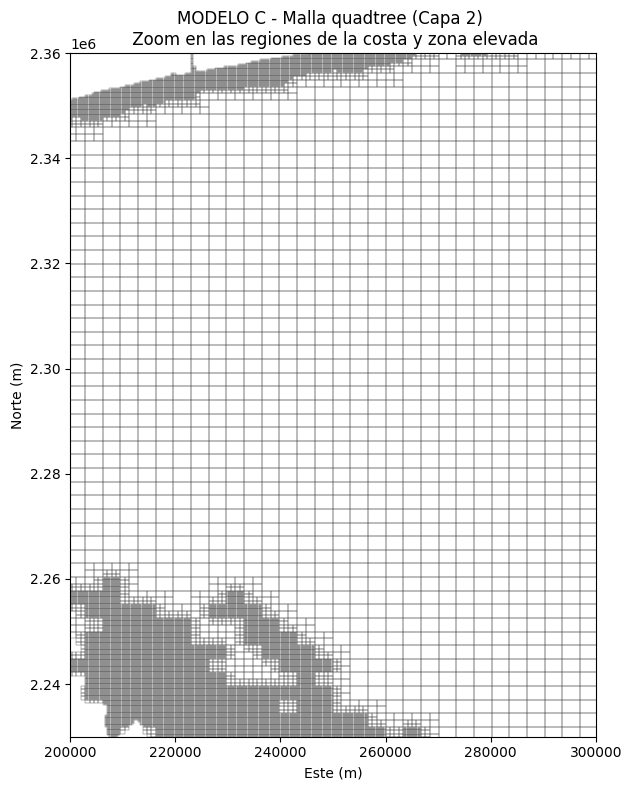

In [28]:
fig, ax = plt.subplots(figsize=(8, 8))

# --- your existing grid plot command here ---
# e.g., qtg.plot(ax=ax) or pc = PatchCollection(...); ax.add_collection(pc)
g.plot(ax=ax, layer=1, edgecolor='0.3', linewidth=0.3)

ax.set_title("MODELO C - Malla quadtree (Capa 2) \n Zoom en las regiones de la costa y zona elevada")
ax.set_xlabel("Este (m)")
ax.set_ylabel("Norte (m)")
# Replace these with the bounding box of the cenote ring in your coordinates:
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_aspect("equal")
plt.tight_layout()
plt.show()


In [29]:
## RETRIEVE A DICTIONARY OF ARGUMENTS TO BE PASSED
## DIRECTLY INTO THE FLOPY DISU CONSTRUCTOR

disu_gridprops = g.get_gridprops_disu6() #return a dictionary containing all of the information required to create a MODFLOW6 DISU package.
                                         # The returned dictinary can be unpackaed directly into the ModflowGwfdisu constructor
disu_gridprops.keys()

dict_keys(['nodes', 'top', 'bot', 'area', 'iac', 'nja', 'ja', 'cl12', 'ihc', 'hwva', 'angldegx', 'nvert', 'vertices', 'cell2d'])

In [30]:
gridprops_ug = g.get_gridprops_unstructuredgrid() # get a dictionary of information needed to create a flopy unstructuredGrid. 
                                                  # The returned dictionary can be unpacked directly into the flopy.discretization.UnstructuredGrid() constructor.
ugrid = flopy.discretization.UnstructuredGrid(**gridprops_ug) ##

gridprops_ug.keys()

dict_keys(['vertices', 'iverts', 'ncpl', 'xcenters', 'ycenters', 'top', 'botm', 'iac', 'ja'])

In [31]:
gridprops_ug['ncpl']

array([14517, 44251])

In [32]:
# layer = np.concatenate([np.zeros(gridprops_ug['ncpl'][0]), np.ones(gridprops_ug['ncpl'][1])])

# z = disu_gridprops["cell2d"]
# cell2d_csv = pd.DataFrame(z)
# cell2d_csv

# cell2d_csv.drop(cell2d_csv.columns[[3,4,5,6,7,8]], axis=1, inplace=True)
# #cell2d_csv.rename(columns={0: 'node', 1: 'x', 2:'y'})
# cell2d_csv["layer"] = layer.astype(int)
# cell2d_csv.to_csv('MF6_node_centroid.csv', index=False)

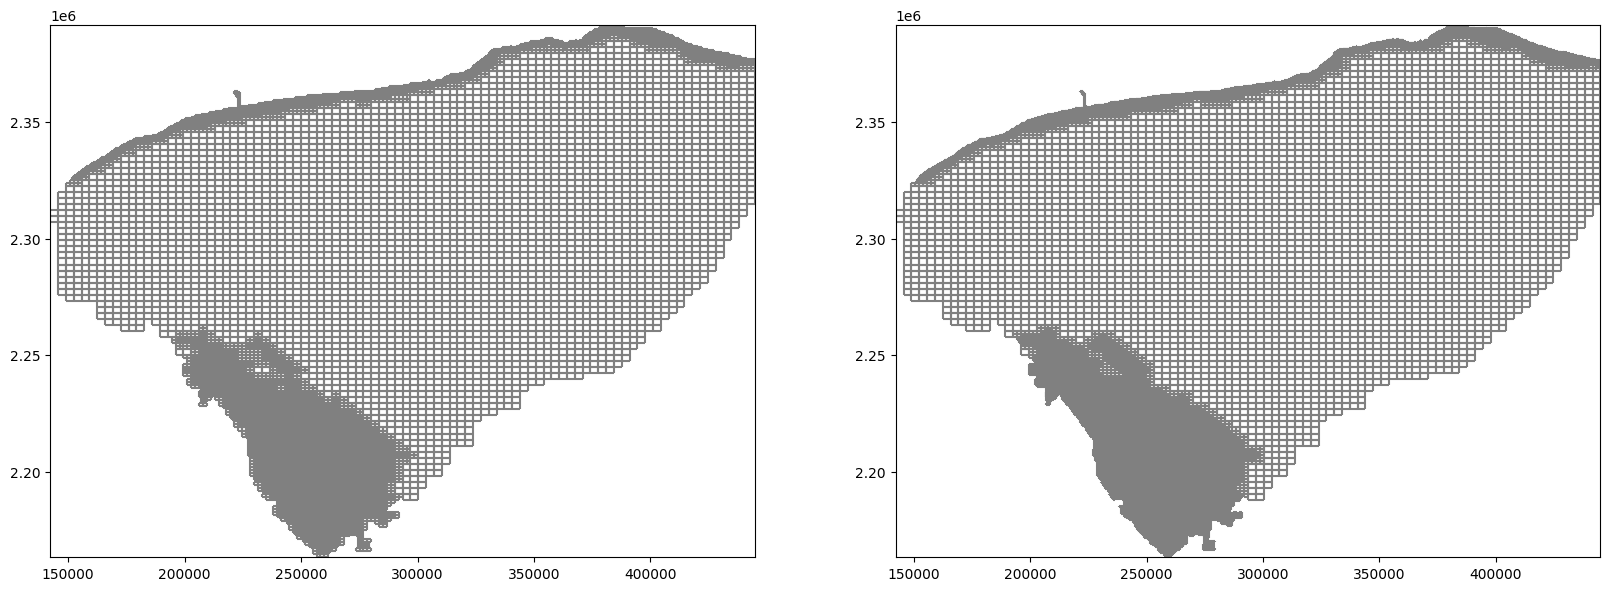

In [33]:
f = plt.figure(figsize=(20,20))
for ilay in range(g.nlay):
    ax = plt.subplot(1, g.nlay, ilay+1)
    ugrid.plot(layer=ilay, ax=ax)

In [34]:
# yucatanRaster_unstructured = yucatan_raster.resample_to_grid(ugrid, band=yucatan_raster.bands[0], method='nearest', extrapolate_edges=True)
# np.save("yucatanRaster_unstructured.npy", yucatanRaster_unstructured)

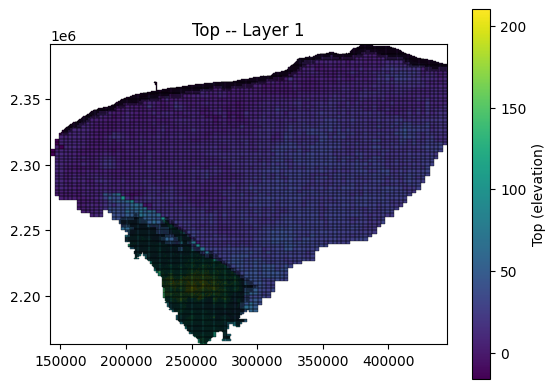

In [35]:
pmv = flopy.plot.PlotMapView(modelgrid=ugrid, layer=0)
pc = pmv.plot_array(yucatanRaster_unstructured)
pmv.plot_grid(lw=0.25, color='k')
plt.colorbar(pc, label='Top (elevation)')
plt.title("Top -- Layer 1")
plt.gca().set_aspect('equal'); plt.show()

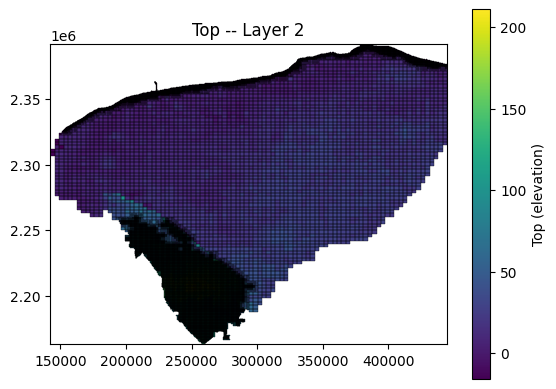

In [36]:
pmv = flopy.plot.PlotMapView(modelgrid=ugrid, layer=1)
pc = pmv.plot_array(yucatanRaster_unstructured)
pmv.plot_grid(lw=0.25, color='k')
plt.colorbar(pc, label='Top (elevation)')
plt.title("Top -- Layer 2")
plt.gca().set_aspect('equal'); plt.show()

Text(0.5, 1.0, 'Original base grid 90x90 cells (Layer 1)')

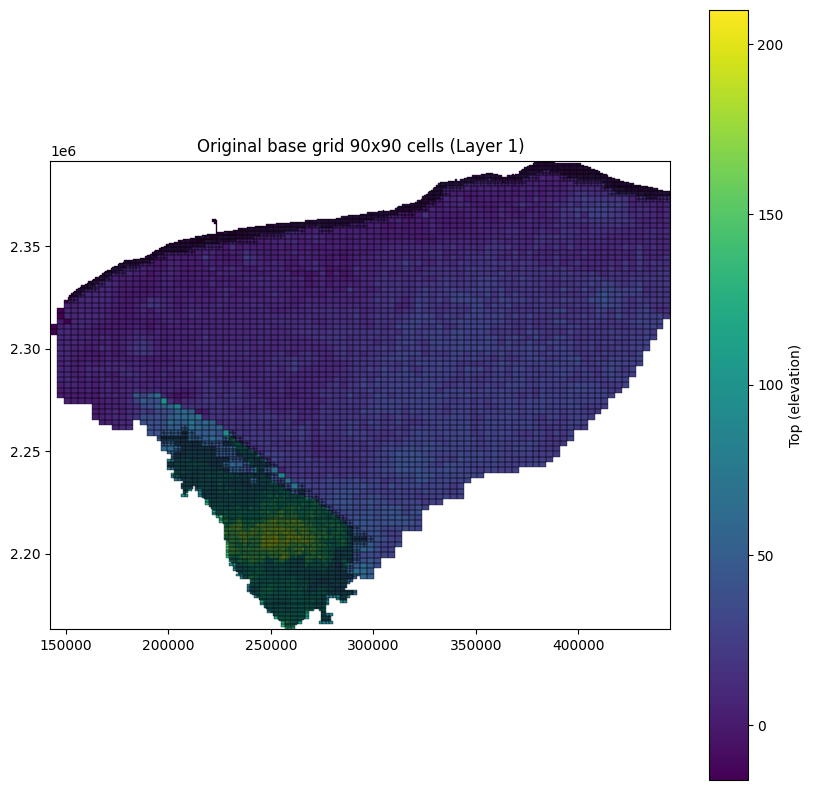

In [37]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1, aspect='equal')
#g.plot(ax, layer=0, edgecolor='k', linewidth=0.5)
pmv = flopy.plot.PlotMapView(modelgrid=ugrid, layer=0)
pc = pmv.plot_array(yucatanRaster_unstructured)
pmv.plot_grid(lw=0.25, color='k')
plt.colorbar(pc, label='Top (elevation)')
plt.title('Original base grid 90x90 cells (Layer 1)')

Text(0.5, 1.0, 'Original base grid 90x90 cells (Layer 2)')

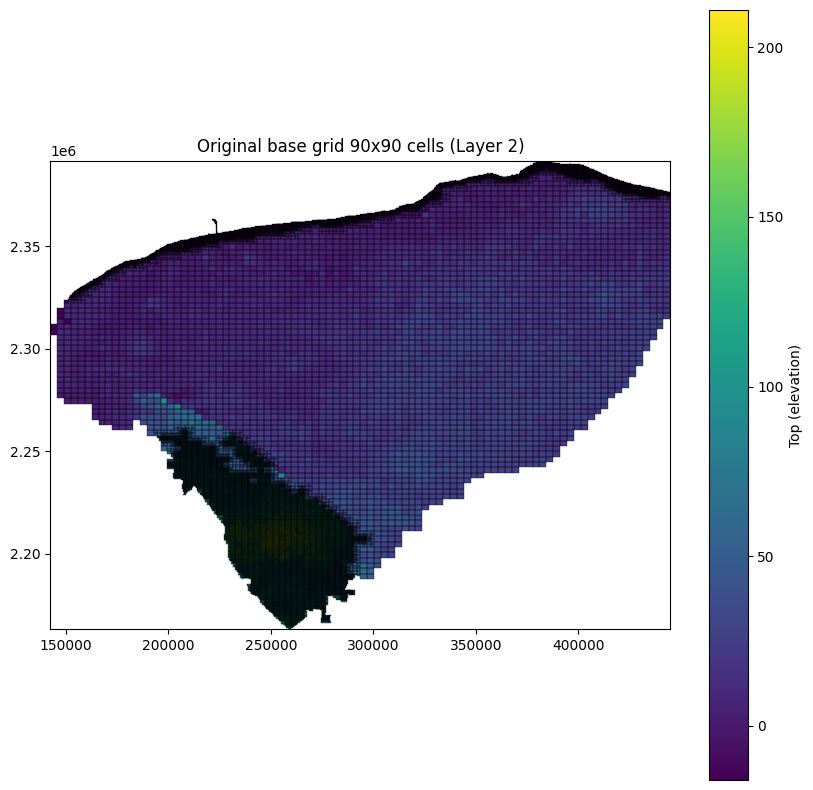

In [38]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1, aspect='equal')
#g.plot(ax, layer=1, edgecolor='k', linewidth=0.5)
pmv = flopy.plot.PlotMapView(modelgrid=ugrid, layer=1)
pc = pmv.plot_array(yucatanRaster_unstructured)
pmv.plot_grid(lw=0.25, color='k')
plt.colorbar(pc, label='Top (elevation)')
plt.title('Original base grid 90x90 cells (Layer 2)')

In [39]:
ws = os.path.join('.', "gridgen_disu")
name = "DISU_model"
sim = flopy.mf6.MFSimulation(
    sim_name=name, sim_ws=ws, exe_name="mf6", verbosity_level=1
)

In [40]:
tdis = flopy.mf6.modflow.mftdis.ModflowTdis(
    sim, pname='tdis', time_units='SECONDS', nper=1, perioddata=[(1.0,1,1.0)]
)

In [41]:
### CREATE HE FLOPY INTERACTIVE MODEL SOLVER (IMS) PACKAGE OBJECT
ims = flopy.mf6.modflow.mfims.ModflowIms(sim,pname='ims',

                                         complexity='complex', # chooses a set of a reasonable defaults and lighter logging.

                                         outer_dvclose=1e-3, ## convergence criterion for the outer (non-linear) loop based on the max change in primary variables (heads). Stops outer iterations when thr max head change between consecutive outer iterations is < 1e-3 (meters)


                                         outer_maximum=300, #hard cap (limit) on the number of outer iterations per time step.... if you hit this number, the non-linear problem isn't settling (often a physics/etup issue, not just solver settings).


                                         inner_dvclose=1e-6,  ## convergence criterion for the inner (linear) solver, it stops the Krylov/CG iterations when the solution update is small enough.
                                                              ## typical range: 1e-4 to 1e-6 (dimesionless, solver-norm based), for stability with unconfined flow, 1e-5 or 1e-6 can reduce outer churn (fewer outer steps wasted on sloppy inner solves).

                                         inner_maximum=1200, # hard cap on inner iterations per outer step. If you frequently hit this cap, the matrix is hard to solve (constrant in K, dry/rewet, weird BCs)

                                         linear_acceleration="BICGSTAB", ## chooses the iterative linear solver. BICGSTAB: handles non-symmetric, ill-conditioned systems better tahn CG--good for unconfined and heterogeneus cases. CG:is fine (and often faster) for symmetric positive definite systems (e.g., confined, gentle K fileds). If CG stalls, go back to BICGSTAB

                                         relaxation_factor=0.92, ## damps updates in the outer loop (under-relaxation). 1.0 = no damping (fast but can oscillat/diverge). 0.7-0.98: is common. 0.97is a gentle brake--good for unconfined/coastal models.
                                                                 # if you see oscillation (outer iterations bouncing), drop to 0.9-0.95
                                                                 # if it's painfully slow but stable, try 0.98-0.99

                                        print_option = 'SUMMARY'
                                        )

In [42]:
## CREATE THE FLOPY GROUNDWATER FLOW MODEL OBJECT
#gwf = flopy.mf6.ModflowGwf(sim,modelname=name, save_flows=True, newtonoptions='under_relaxation')
gwf = flopy.mf6.ModflowGwf(sim,modelname=name, save_flows=True)

gwf.modelgrid.crs = modelgrid.crs
#gwf.modelgrid.set_coord_info(xoff=modelgrid._xoff, yoff=modelgrid._yoff, angrot=modelgrid._angrot, crs=modelgrid._crs)

[<AxesSubplot:title={'center':'top layer 1'}>,
 <AxesSubplot:title={'center':'top layer 2'}>,
 <AxesSubplot:title={'center':'bot layer 1'}>,
 <AxesSubplot:title={'center':'bot layer 2'}>,
 <AxesSubplot:title={'center':'area layer 1'}>,
 <AxesSubplot:title={'center':'area layer 2'}>,
 <AxesSubplot:title={'center':'iac layer 1'}>,
 <AxesSubplot:title={'center':'iac layer 2'}>]

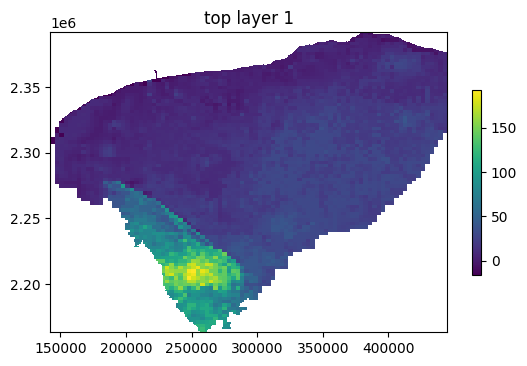

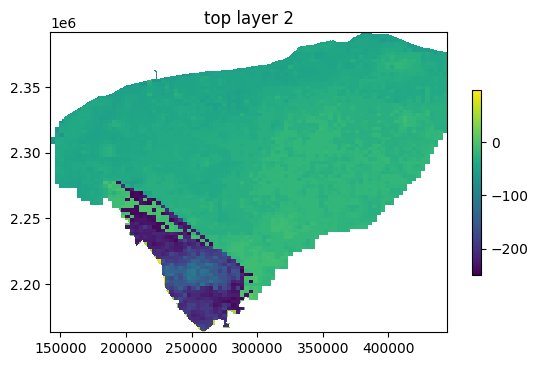

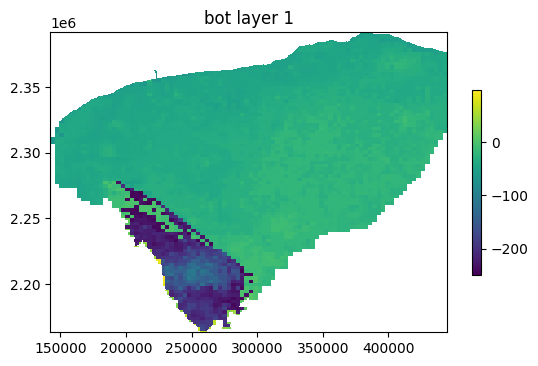

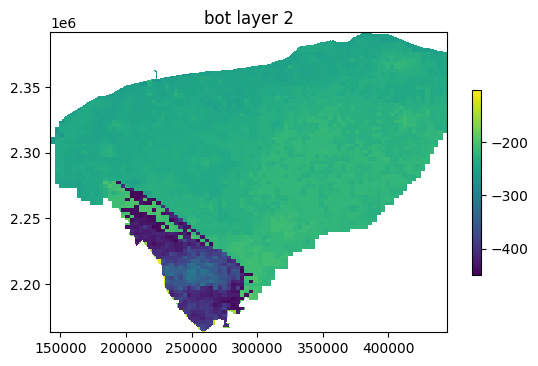

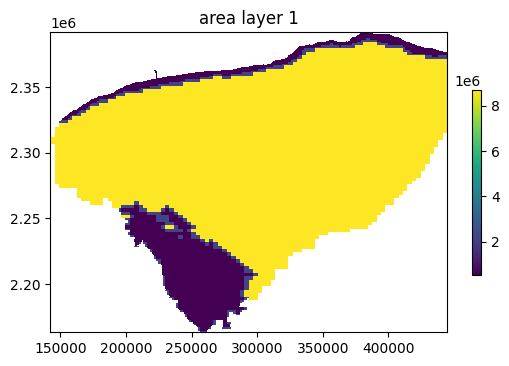

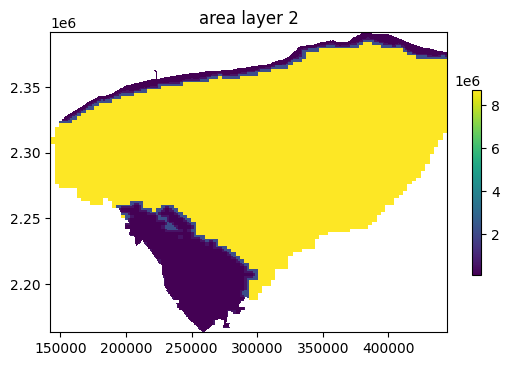

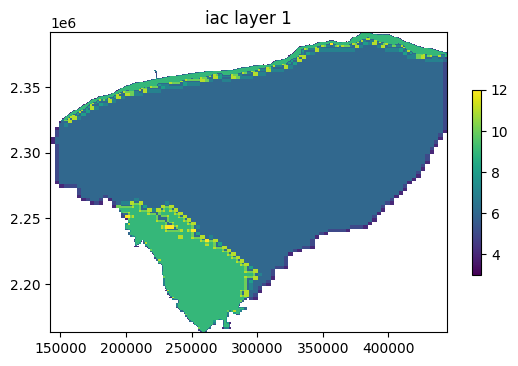

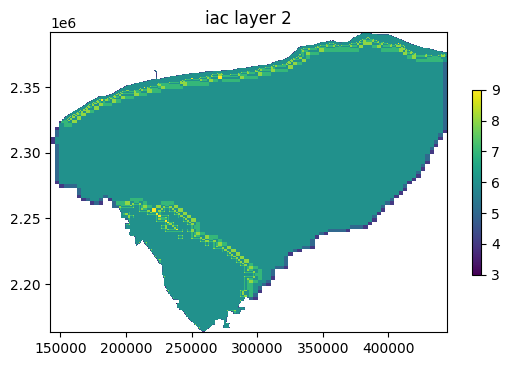

In [43]:
disu = flopy.mf6.ModflowGwfdisu(gwf, length_units="METERS", nodes=disu_gridprops["nodes"], nja=disu_gridprops["nja"], nvert=disu_gridprops["nvert"], top=gridprops_ug["top"], bot=gridprops_ug["botm"], area=disu_gridprops["area"], iac=disu_gridprops["iac"], ja=disu_gridprops["ja"], ihc=disu_gridprops["ihc"], cl12=disu_gridprops["cl12"], hwva=disu_gridprops["hwva"], angldegx=0,vertices=disu_gridprops["vertices"], cell2d=disu_gridprops["cell2d"])
disu.plot()

INTERPOLATION OF PIEZOMETRIC DATA

In [44]:
### BUILDING OBSERVATION ARRAYS FOR INTERPOLATION

# observed wells coordinates in meters
xy_obs = np.vstack([df.x.values, df.y.values]).T #shape [n_points,2]

z_obs = df.median_head_masl.values.astype(float) #head at wells
w_obs = df.weight.values.astype(float)  #weigts 0-1 (more measurements -> higher weight)

w_obs = np.clip(w_obs,1e-6,None) #prevents divide-by-zero

In [45]:
## Building the query grid = model cell centers to interpolate onto
# modelgrid.xcellcenters, modelgrid.ycellcenters ----> 1D arrays of X and Y for each column/row

Xc = gridprops_ug["xcenters"]
Yc = gridprops_ug["ycenters"]

xy_q = np.vstack([Xc.ravel(),Yc.ravel()]).T #shape [nrow*ncol,2]

In [46]:
def idw_weighted_knn(xy_obs, z_obs, w_obs, xy_q,k, power, eps=1e-12, exact_tol=1e-9,normalize_weights=True, return_diag=False):

    # 1) filter invalid obs
    obs_ok = np.isfinite(z_obs) & np.isfinite(w_obs)
    xy_o = xy_obs[obs_ok]; z_o = z_obs[obs_ok]; w_o = w_obs[obs_ok]
    if xy_o.shape[0] == 0:
        raise ValueError("No valid observations after filtering.")

    # 2) clamp k
    k = int(min(max(1, k), xy_o.shape[0]))

    # 3) normalize obs weights (optional but helpful)
    w = np.clip(w_o, 1e-12, None)
    if normalize_weights:
        med = np.nanmedian(w)
        if np.isfinite(med) and med > 0:
            w = w / med

    # 4) KD-tree query
    tree = cKDTree(xy_o)
    dist, idx = tree.query(xy_q, k=k, p=2, workers=-1)
    if k == 1:
        dist = dist[:, None]
        idx  = idx[:,  None]

    # 5) exact matches
    exact = dist[:, 0] <= exact_tol

    # 6) weights (avoid inf, 0)
    d = np.maximum(dist, eps)
    wd = (w[idx] / d**power)
    wd_sum = wd.sum(axis=1)

    # 7) interpolate
    zi = np.full(xy_q.shape[0], np.nan, dtype=float)
    not_exact = ~exact
    if np.any(not_exact):
        num = np.sum(wd[not_exact] * z_o[idx[not_exact]], axis=1)
        den = np.maximum(wd_sum[not_exact], eps)
        zi[not_exact] = num / den

    # 8) copy exact obs values directly
    if np.any(exact):
        zi[exact] = z_o[idx[exact, 0]]

    if return_diag:
        return zi, {"exact": exact, "wd_sum": wd_sum, "dist_min": dist[:,0]}
    return zi

In [47]:
head_idw = idw_weighted_knn(xy_obs,z_obs,w_obs,xy_q,14,2.5)

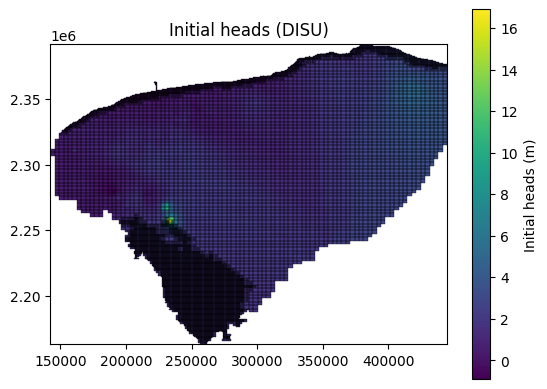

In [48]:
## Plot of the interpolated piezometric data

pmv = flopy.plot.PlotMapView(modelgrid=gwf.modelgrid)
pc = pmv.plot_array(head_idw)
pmv.plot_grid(lw=0.25, color='k')
plt.colorbar(pc, label='Initial heads (m)')
plt.title("Initial heads (DISU)")
plt.gca().set_aspect('equal'); plt.show()

[<AxesSubplot:title={'center':'strt layer 1'}>,
 <AxesSubplot:title={'center':'strt layer 2'}>]

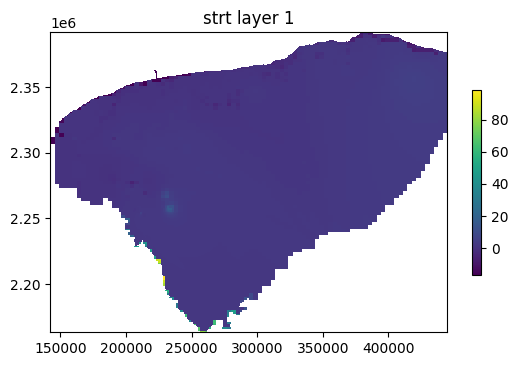

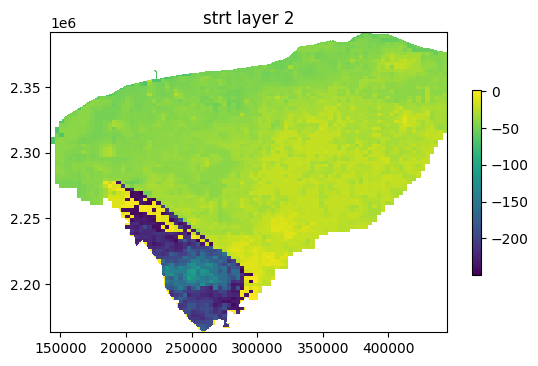

In [49]:
### CLIP TO HYDROGEOLOGY AND BUILD LAYERED INITIAL CONDITIONS (strt)
    # Layer 1: head must be within [bottom_L1 + e, top - e]
    # Layer 2: head must be <= Layer 1 >= bottom_layer2+e
    # This prevents illegal starting head and helps convergence.

off = np.concatenate(([0], np.cumsum(gridprops_ug["ncpl"])))
idx_l1 = np.arange(off[0], off[1])
idx_l2 = np.arange(off[1], off[2])

strt = np.zeros_like(head_idw)

strt[idx_l1] = np.clip(
    head_idw[idx_l1],
    gwf.modelgrid.botm[idx_l1]+0.5,
    gwf.modelgrid.top[idx_l1]-0.5
    )

strt[idx_l2] = np.clip(
    head_idw[idx_l2],
    gwf.modelgrid.botm[idx_l2]+0.5,
    gwf.modelgrid.top[idx_l2]-0.5
    )


## Create the initial conditions package
ic = flopy.mf6.modflow.mfgwfic.ModflowGwfic(gwf, pname='ic', strt=strt)
ic.plot()

In [50]:
from shapely.prepared import prep

coast_buf = coastline.buffer(1500.0)
coast_u = coast_buf.union_all()
coast_buf_prep = prep(coast_u)

Number of CHD nodes: 9044
First few: [0 1 2 3 4 5 6 7 8 9]


[<AxesSubplot:title={'center':' chd location stress period 1 layer 1'}>,
 <AxesSubplot:title={'center':' chd location stress period 1 layer 2'}>]

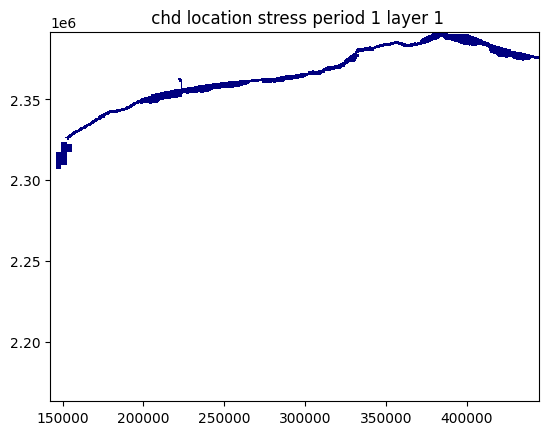

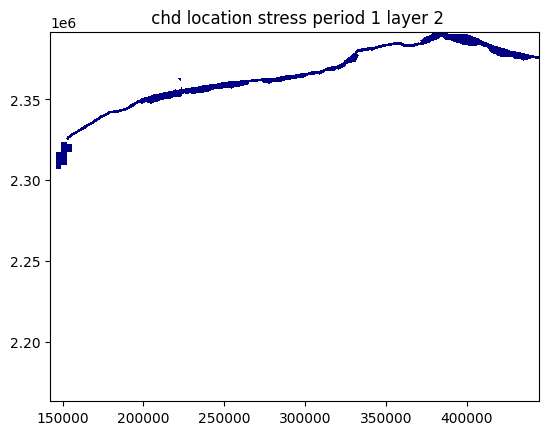

In [51]:
## BUILD THE CHD PACKAGE

nnodes = disu_gridprops['nodes']
chd_nodes = np.zeros(nnodes, dtype=bool)

for nid, (x,y) in enumerate(zip(Xc,Yc)):
    # if not disu.idomain[nid]: #skip inactive cells
    #     continue
    if coast_buf_prep.contains(Point(x,y)):
        chd_nodes[nid] = True

chd_cellids = np.where(chd_nodes)[0].astype(int)
print("Number of CHD nodes:", len(chd_cellids))
print("First few:", chd_cellids[:10])

chd_spd = [
    [(int(nid),), 0.0] #cellid, hstart, hend
    for nid in chd_cellids
]


chd = flopy.mf6.modflow.mfgwfchd.ModflowGwfchd(
    gwf,
    pname="chd",
    stress_period_data={0: chd_spd},
    save_flows=True,
)

chd.plot()

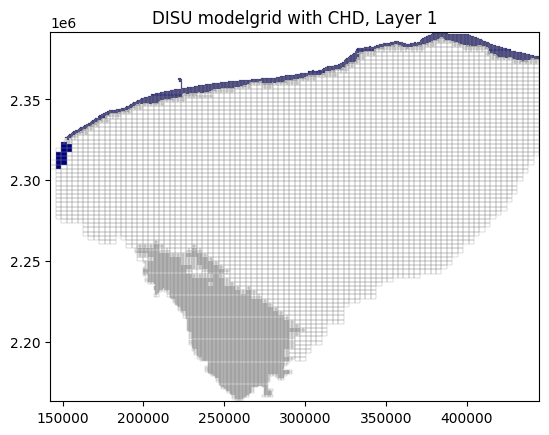

In [52]:
pmv = flopy.plot.PlotMapView(modelgrid=gwf.modelgrid,layer=0)
pmv.plot_grid(lw=0.2)
#pmv.plot_ibound(gwf.modelgrid.idomain)
pmv.plot_bc(name='chd', package=chd, kper=0)
plt.title("DISU modelgrid with CHD, Layer 1")
plt.gca().set_aspect('equal'); plt.show()

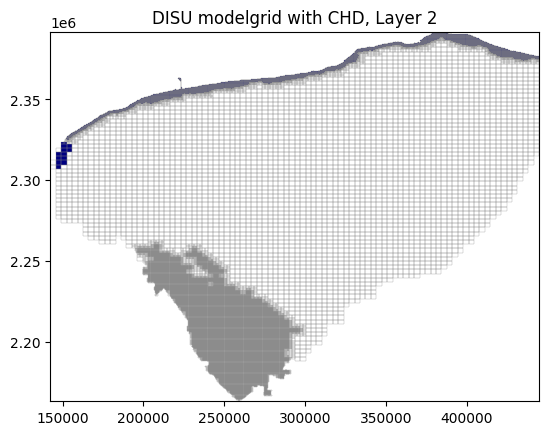

In [53]:
pmv = flopy.plot.PlotMapView(modelgrid=gwf.modelgrid,layer=1)
pmv.plot_grid(lw=0.2)
#pmv.plot_ibound(gwf.modelgrid.idomain)
pmv.plot_bc(name='chd', package=chd, kper=0)
plt.title("DISU modelgrid with CHD, Layer 2")
plt.gca().set_aspect('equal'); plt.show()

In [54]:
upland_nodes = np.zeros(nnodes, dtype=bool)

for nid, (x,y) in enumerate(zip(Xc,Yc)):
    if ref_poly.contains(Point(x,y)):
        upland_nodes[nid] = True

upland_cellids = np.where(upland_nodes)[0].astype(int)

In [55]:
np.save("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\yucatan_modelC\\quadtreeGrid\\gridgen_disu\\upland_cellids.npy", upland_cellids)

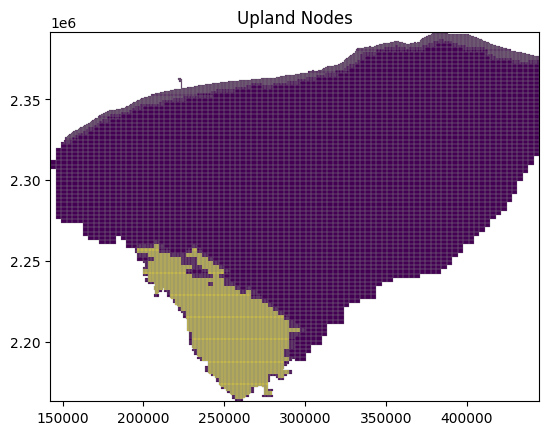

In [56]:
pmv = flopy.plot.PlotMapView(modelgrid=gwf.modelgrid,layer=0)
pmv.plot_grid(lw=0.2)
pmv.plot_array(upland_nodes)
#pmv.plot_ibound(gwf.modelgrid.idomain)
#pmv.plot_bc(name='chd', package=chd, kper=0)
plt.title("Upland Nodes")
plt.gca().set_aspect('equal'); plt.show()

[<AxesSubplot:title={'center':'icelltype layer 1'}>,
 <AxesSubplot:title={'center':'icelltype layer 2'}>,
 <AxesSubplot:title={'center':'k layer 1'}>,
 <AxesSubplot:title={'center':'k layer 2'}>]

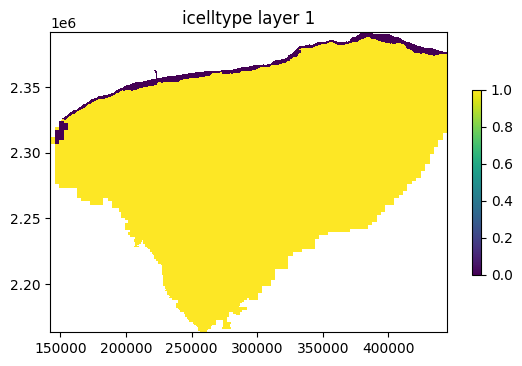

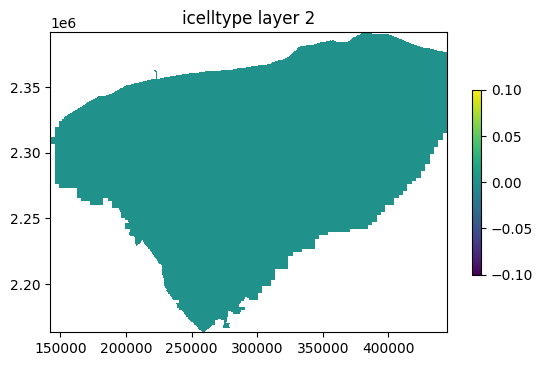

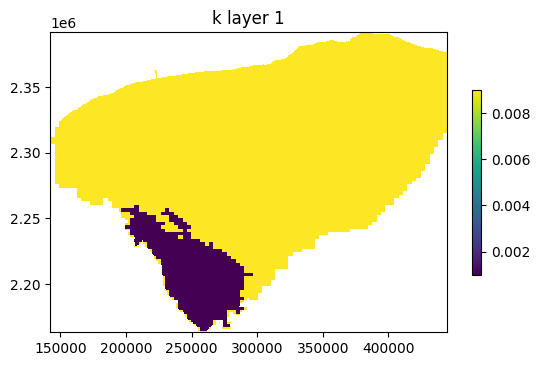

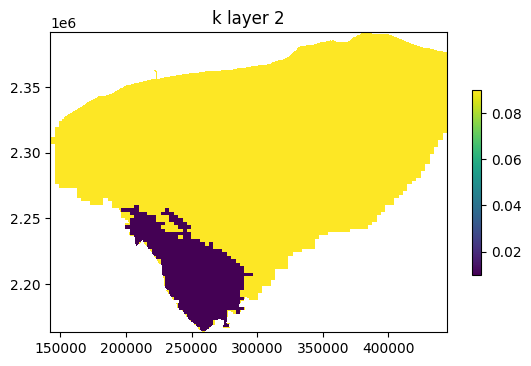

In [57]:
# Create the node property flow package
## icelltype = 1 for Layer 1 (unconfined: saturated thickness varies with computed head when head is below the cell top)
## icelltype = 0 for layer 2 (confined: means that saturated thickness is held constant)

### Creation of the icelltype for the layers, Layer 0: Unconfined (except for the confined coast), Layer 1: Confined
un_confined_layers = np.zeros(disu_gridprops["nodes"], dtype=int)

for idx in range(off[1]):
    if idx not in chd_cellids:
        un_confined_layers[idx] = 1.0


k = np.ones(nnodes)

for idx in range(off[1]):
    if idx in upland_cellids:
        k[idx] = 1e-3
    else:
        k[idx] = 9e-3

for idx in range(off[1], off[2]):
    if idx in upland_cellids:
        k[idx] = 1e-2
    else:
        k[idx] = 9e-2


### NODE PROPERTY FLOW PACKAGE CREATION 
npf = flopy.mf6.modflow.mfgwfnpf.ModflowGwfnpf(
    gwf, pname='npf', icelltype=un_confined_layers, k=k, save_flows=True, save_specific_discharge=True,
)

npf.plot()

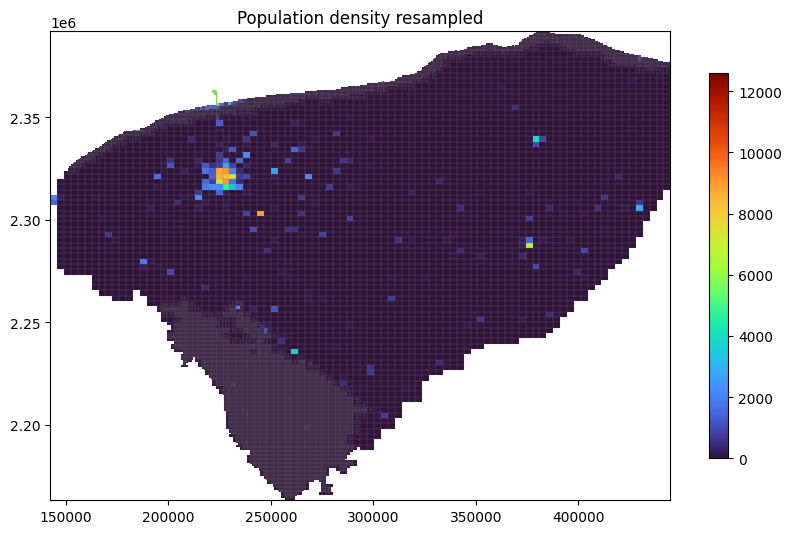

In [58]:
populationRaster_remuestreado = population_raster.resample_to_grid(gwf.modelgrid, band=population_raster.bands[0], method='nearest', extrapolate_edges=True)
############
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1, aspect='equal')
pmv = flopy.plot.PlotMapView(modelgrid=gwf.modelgrid,ax=ax,layer=0)
pmv.plot_grid(ax=ax, lw=0.1)
ax = pmv.plot_array(populationRaster_remuestreado, masked_values=population_raster.nodatavals, cmap="turbo")
plt.title("Population density resampled")
plt.colorbar(ax, shrink=0.5)

WEL nodes: 43344 | total pumping m3/s = -76.709481


[<AxesSubplot:title={'center':' well_casec location stress period 1 layer 1'}>,
 <AxesSubplot:title={'center':' well_casec location stress period 1 layer 2'}>]

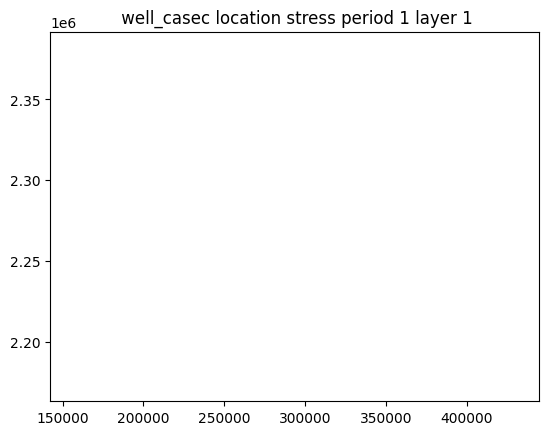

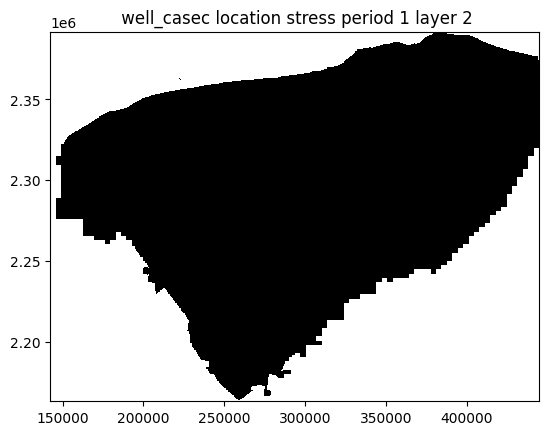

In [59]:
wel_list = []
Hm3yr_to_m3s = 1e6 / (365.25 * 86400.0)

# candidate_nodes = layer 2 nodes (you said off[1], off[2] define this range)
candidate_nodes = np.arange(off[1], off[2])  # make sure off is correct

for idx, row in well_data.iterrows():
    Q_m3s = float(row["total"]) * Hm3yr_to_m3s
    geom = row.geometry

    # skip invalid/no-pumping
    if Q_m3s <= 0 or geom is None or geom.is_empty:
        continue

    # CRS check
    if well_data.crs is not None and well_data.crs != gwf.modelgrid.crs:
        raise RuntimeError("Reproject well_data to model CRS before looping.")

    gprep = prep(geom)

    # find layer-2 nodes within this municipality
    nodes_in_muni = []
    for nid in candidate_nodes:
        x, y = Xc[nid], Yc[nid]
        if gprep.contains(Point(x, y)):
            nodes_in_muni.append(nid)

    if not nodes_in_muni:
        continue

    nodes_in_muni = np.array(nodes_in_muni, dtype=int)

    # population weights
    w = populationRaster_remuestreado[nodes_in_muni].astype(float)

    # fallback if pop is bad
    if (not np.isfinite(w).any()) or np.all(w <= 0):
        w = np.ones_like(nodes_in_muni, dtype=float)

    wsum = float(w.sum())
    if wsum <= 0.0:
        w = np.ones_like(nodes_in_muni, dtype=float)
        wsum = float(w.sum())

    # distribute Q across these nodes
    rates = -Q_m3s * (w / wsum)

    for nid, q in zip(nodes_in_muni, rates):
        # MF6 DISU WEL: ( (node_id,), rate )
        wel_list.append(((int(nid),), float(q)))

## CCreate the well package
wel = flopy.mf6.modflow.mfgwfwel.ModflowGwfwel(
    gwf,
    pname="well_caseC",
    save_flows=True,
    stress_period_data={0: wel_list},
)

total_Q = sum(q for (_, q) in wel_list)
print(f"WEL nodes: {len(wel_list)} | total pumping m3/s = {total_Q:.6f}")
wel.plot()


In [60]:
# Layer 0 (should be empty)
# pmv = flopy.plot.PlotMapView(model=gwf, layer=0)
# pmv.plot_bc("WEL", kper=0)
# pmv.ax.set_title("WEL cells – Layer 1 (should be none)")

# Layer 1 (your wells)
# pmv = flopy.plot.PlotMapView(model=gwf, layer=1)
# pmv.plot_bc("WEL", kper=0)
# pmv.ax.set_title("WEL cells – Layer 2")

In [61]:
### loading the evaporation and precipitation data 
x = []
y = []
prec_values = []
prec_weight_values = []

folder = Path("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\precipitation_data")
for fp in folder.glob("*.csv"):
    #read the file
    df = pd.read_csv(fp)
    # ## extract coordinates values
    x_val = df["x"].dropna().values
    y_val = df["y"].dropna().values
    x.extend(x_val)
    y.extend(y_val)
    # extract precipitation data value
    prec_data = (df["mean_of_acum"].dropna().values) 
    prec_values.extend(prec_data) 
    # extract the weight data
        #For the case A use 25% of mean annual precipitation
    #weight_data = (df["weight"].dropna().values) * 0.25
    weight_data = (df["weight"].dropna().values) 
    prec_weight_values.extend(weight_data)
    
x_coords = np.array(x)
y_coords = np.array(y)
clima_coords = np.column_stack((x_coords, y_coords))
prec_values = np.array(prec_values)
prec_weight_values = np.array(prec_weight_values)

In [62]:
### interpolation of the precipitation data
prec_idw = idw_weighted_knn(clima_coords,prec_values,prec_weight_values,xy_q,12,2.0)

[<AxesSubplot:title={'center':' rch location stress period 1 layer 1'}>,
 <AxesSubplot:title={'center':' rch location stress period 1 layer 2'}>]

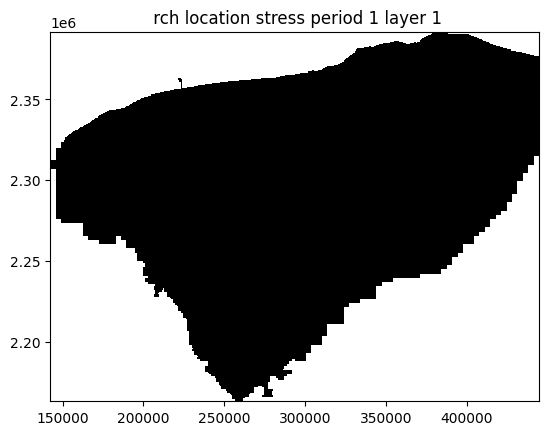

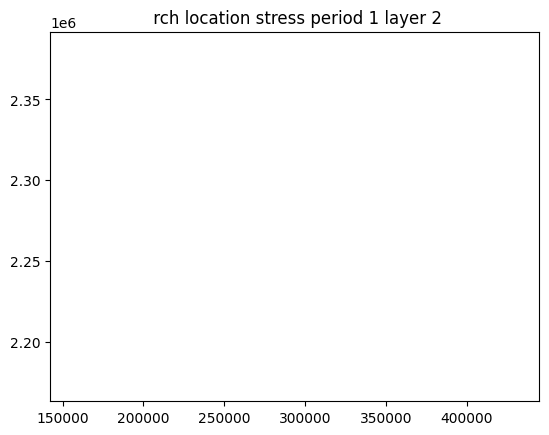

In [63]:
## creating the recharge package
sec_per_year = 365*86400 #seconds in a year
c_inf = 0.25 #infiltration coefficient
mR_upland = 1.0
mR_rest = 1.0

recharge = (prec_idw*1e-3*c_inf) / sec_per_year #recharge in meters per seconds
recharge[upland_cellids] *= mR_upland
recharge[~upland_cellids] *= mR_rest

records = [((int(node),), float(recharge[node])) for node in idx_l1]

if "rch" in gwf.get_package_list():
    gwf.remove_package("rch")
    
# CREATE THE RECHARGE (PRECIPITATION DATA) PACKAGE
rch = flopy.mf6.ModflowGwfrch(
    gwf,
    stress_period_data = {0:records}, #steady state; 1 period
    pname="rch",
    fixed_cell=True,
    print_flows=True,
    filename = "quadtree_caseC.rch",
    save_flows=True,
)

rch.plot()

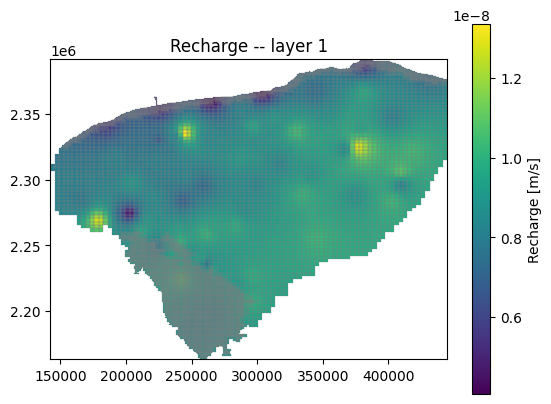

In [64]:
pmv = flopy.plot.PlotMapView(modelgrid=gwf.modelgrid,layer=0)
#pmv.plot_bc(name='chd', package=chd, kper=0)
pc = pmv.plot_array(recharge)
cb = plt.colorbar(pc); cb.set_label("Recharge [m/s]")
pmv.plot_grid(lw=0.2)
pmv.plot_ibound(gwf.modelgrid.idomain)
plt.title("Recharge -- layer 1")
plt.gca().set_aspect('equal'); plt.show()

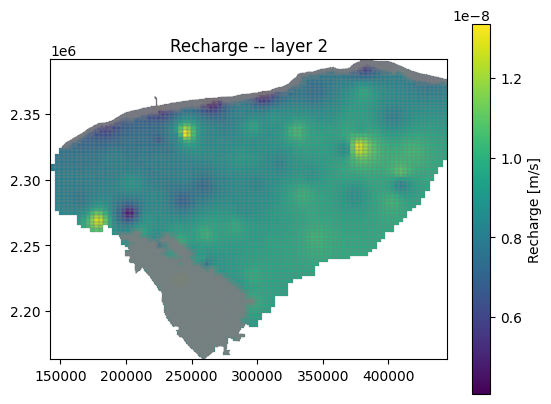

In [65]:
pmv = flopy.plot.PlotMapView(modelgrid=gwf.modelgrid,layer=1)
#pmv.plot_bc(name='chd', package=chd, kper=0)
pc = pmv.plot_array(recharge)
cb = plt.colorbar(pc); cb.set_label("Recharge [m/s]")
pmv.plot_grid(lw=0.2)
pmv.plot_ibound(gwf.modelgrid.idomain)
plt.title("Recharge -- layer 2")
plt.gca().set_aspect('equal'); plt.show()

In [66]:
#wrap longitudes to [-180, 180] if needed and sort

if 'longitude' in data.coords:
    lon = data['longitude']
    if float(lon.max()) > 180.0: #ERA5 often 0..360
        data = data.assign_coords(longitude=((lon+180)%360) - 180).sortby('longitude')

if 'longitude' in pressure_data.coords:
    lon = pressure_data['longitude']
    if float(lon.max()) > 180.0: #ERA5 often 0..360
        pressure_data = pressure_data.assign_coords(longitude=((lon+180)%360) - 180).sortby('longitude')

print(data)

<xarray.Dataset> Size: 55GB
Dimensions:     (valid_time: 356, latitude: 1801, longitude: 3600)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 3kB 1996-01-01 ... 2025-08-01
  * latitude    (latitude) float64 14kB 90.0 89.9 89.8 ... -89.8 -89.9 -90.0
    expver      (valid_time) <U4 6kB dask.array<chunksize=(356,), meta=np.ndarray>
  * longitude   (longitude) float64 29kB -179.9 -179.8 -179.7 ... 179.9 180.0
Data variables:
    d2m         (valid_time, latitude, longitude) float32 9GB dask.array<chunksize=(40, 400, 400), meta=np.ndarray>
    t2m         (valid_time, latitude, longitude) float32 9GB dask.array<chunksize=(40, 400, 400), meta=np.ndarray>
    ssr         (valid_time, latitude, longitude) float32 9GB dask.array<chunksize=(40, 400, 400), meta=np.ndarray>
    str         (valid_time, latitude, longitude) float32 9GB dask.array<chunksize=(40, 400, 400), meta=np.ndarray>
    u10         (valid_time, latitude, longitude) float32 9GB dask.arra

In [67]:
data['d2m']

<xarray.DataArray 'd2m' (valid_time: 356, latitude: 1801, longitude: 3600)> Size: 9GB
dask.array<getitem, shape=(356, 1801, 3600), dtype=float32, chunksize=(40, 400, 400), chunktype=numpy.ndarray>
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 3kB 1996-01-01 ... 2025-08-01
  * latitude    (latitude) float64 14kB 90.0 89.9 89.8 ... -89.8 -89.9 -90.0
    expver      (valid_time) <U4 6kB dask.array<chunksize=(356,), meta=np.ndarray>
  * longitude   (longitude) float64 29kB -179.9 -179.8 -179.7 ... 179.9 180.0
Attributes: (12/31)
    GRIB_paramId:                             168
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      6483600
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre dewpoint temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [68]:
data['t2m']

<xarray.DataArray 't2m' (valid_time: 356, latitude: 1801, longitude: 3600)> Size: 9GB
dask.array<getitem, shape=(356, 1801, 3600), dtype=float32, chunksize=(40, 400, 400), chunktype=numpy.ndarray>
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 3kB 1996-01-01 ... 2025-08-01
  * latitude    (latitude) float64 14kB 90.0 89.9 89.8 ... -89.8 -89.9 -90.0
    expver      (valid_time) <U4 6kB dask.array<chunksize=(356,), meta=np.ndarray>
  * longitude   (longitude) float64 29kB -179.9 -179.8 -179.7 ... 179.9 180.0
Attributes: (12/31)
    GRIB_paramId:                             167
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      6483600
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [69]:
from pyproj import Transformer

to_ll = Transformer.from_crs(gwf.modelgrid.crs, "EPSG:4326", always_xy=True)
lon_pts, lat_pts = to_ll.transform(Xc, Yc)  # arrays length ncpl

# ERA5 sometimes 0..360; bring to [-180,180]
lon_pts = ((lon_pts + 180) % 360) - 180

In [70]:
## Clip ERA5 to a tight bbox (speed everything)

pad = 1.0  # degrees margin
lon_min, lon_max = float(lon_pts.min()) - pad, float(lon_pts.max()) + pad
lat_min, lat_max = float(lat_pts.min()) - pad, float(lat_pts.max()) + pad

# If ds uses 0..360 longitudes, convert to [-180,180]
if float(data.longitude.max()) > 180:
    data = data.assign_coords(longitude=((data.longitude + 180) % 360) - 180).sortby("longitude")

data_clip = data.sel(
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_max, lat_min)  #ERA5 lat usually descending; slice(high->low)
)

In [71]:
### INTERPOLATE A VARIABLE AT THE POINT (NO REPROJECTION)
# This will return (time, nodes) or (nodes,) if no time

def interp_to_cells(da_ll, lon_pts, lat_pts, method='nearest'):
    #ensure ascending for xarray interp
    if da_ll.longitude[1] < da_ll.longitude[0]:
        da_ll = da_ll.sortby("longitude")
    if da_ll.latitude[1] > da_ll.latitude[0]:
        da_ll = da_ll.sortby("latitude", ascending=False)
    
    #vectorized point interpolation to new "points" dim
    if "time" in da_ll.dims:
        out = da_ll.interp(longitude=("points", lon_pts),
                           latitude=("points", lat_pts),
                           method=method)
        #shape (time, nodes)
        return out.transpose("time", "points")
    else:
        out = da_ll.interp(longitude=("points", lon_pts),
                           latitude=("points", lat_pts),
                           method=method)
        #output shape: (nodes,)
        return out

ssr_cell = interp_to_cells(data["ssr"], lon_pts, lat_pts)   
str_cell = interp_to_cells(data["str"], lon_pts, lat_pts)
t2m_cell = interp_to_cells(data["t2m"], lon_pts, lat_pts)
d2m_cell = interp_to_cells(data["d2m"], lon_pts, lat_pts)
u10_cell = interp_to_cells(data["u10"], lon_pts, lat_pts)
v10_cell = interp_to_cells(data["v10"], lon_pts, lat_pts)

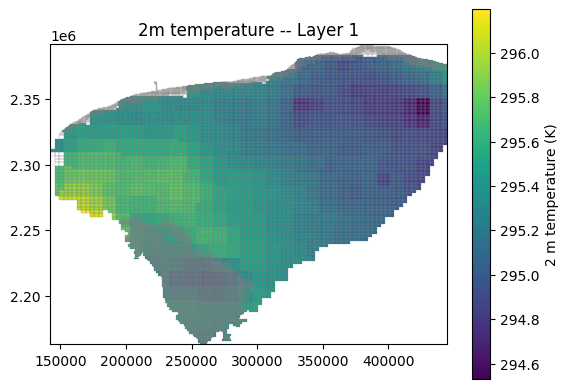

In [72]:
arr = t2m_cell.isel(valid_time=0).values.astype(float)  # (ncpl,)

pmv = flopy.plot.PlotMapView(modelgrid=gwf.modelgrid, layer=0)
pc  = pmv.plot_array(arr)                            # fills cell polygons
pmv.plot_grid(lw=0.2)
cb = plt.colorbar(pc); cb.set_label("2 m temperature (K)")
plt.gca().set_aspect('equal')
plt.title("2m temperature -- Layer 1")
plt.show()

In [73]:

# Wrap the numpy arrays with the ERA5 time index you used
# Here I assume d2m_cell carries the correct time coordinate already.
time = d2m_cell["valid_time"] if isinstance(d2m_cell, xr.DataArray) else None

def as_da(arr, name):
    if isinstance(arr, xr.DataArray):
        return arr
    # arr is numpy with shape (ntime, ncpl)
    return xr.DataArray(arr, dims=("valid_time","points"), coords={"valid_time": time, "points": np.arange(ncpl)}, name=name)

ssr = as_da(ssr_cell, "ssr")   # J/m^2 over the month (ERA5 monthly sums)
strr= as_da(str_cell, "str")
t2m = as_da(t2m_cell, "t2m")   # K
d2m = as_da(d2m_cell, "d2m")   # K
u10 = as_da(u10_cell, "u10")   # m/s
v10 = as_da(v10_cell, "v10")   # m/s
#sp  = as_da(sp_cell,  "sp")    # Pa  (if you don’t have this, we’ll use 101.3 kPa)

#Days in month aligned to ERA5 time:
time_index = ssr["valid_time"].to_index()
days_in_month = xr.DataArray(
    time_index.to_series().dt.days_in_month.values,
    coords={"valid_time": ssr["valid_time"]},
    dims=("valid_time",),
    name="dim"
)

# Radiation: monthly J/m^2  -> daily MJ/m^2/day
Rns = (ssr / days_in_month) / 1e6     # shortwave, MJ m^-2 d^-1
Rnl = (strr / days_in_month) / 1e6    # longwave,  MJ m^-2 d^-1
Rn  = Rns + Rnl                        # net radiation, MJ m^-2 d^-1

# Temperatures: K -> °C
Tmean_C = t2m - 273.15
Tdew_C  = d2m - 273.15

# Wind: 10 m -> 2 m (FAO-56 log-law)
u10mag = xr.apply_ufunc(np.hypot, u10, v10, dask="allowed")
u2 = u10mag * (4.87 / np.log(67.8*10.0 - 5.42))  # ≈ 0.748 * u10

# Saturation vapor pressure (kPa)
def esat_kpa(Tc):
    return 0.6108 * xr.apply_ufunc(np.exp, (17.27*Tc)/(Tc+237.3), dask="allowed")

es = esat_kpa(Tmean_C)   # kPa
ea = esat_kpa(Tdew_C)    # kPa  (dew point ≈ actual vapor pressure)

# Slope of sat. vapour pressure curve (kPa/°C)
delta = (4098.0 * es) / ((Tmean_C + 237.3)**2)

# Psychrometric constant gamma (kPa/°C)
# If you don't trust ERA5 surface pressure, use 101.3 kPa flat:
P_kPa = (sp / 1000.0) if "sp" in locals() and sp is not None else (xr.zeros_like(Tmean_C) + 101.3)
gamma = 0.000665 * P_kPa

# FAO-56 PM (mm/day); soil heat flux G≈0 monthly
T_k = Tmean_C + 273.0
ET0 = (0.408*delta*Rn + gamma*(900.0/T_k)*u2*(es - ea)) / (delta + gamma*(1.0 + 0.34*u2))
ET0 = ET0.clip(min=0.0)     # no negative

EVT cells: 12409


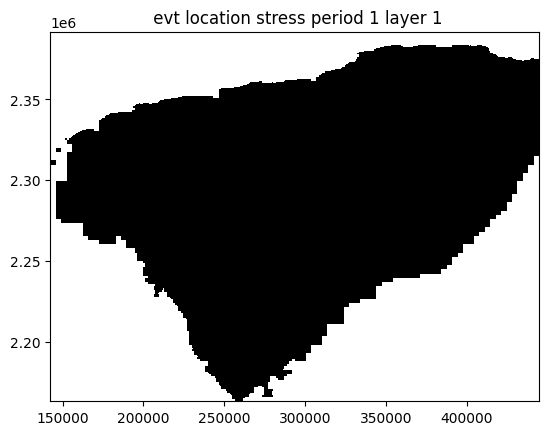

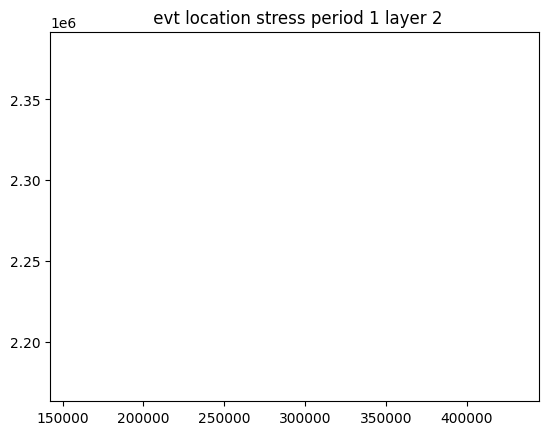

In [74]:
mg = gwf.modelgrid
ncpl = mg.ncpl  # e.g. [38976, 56271]
fgw = 0.3 #Ground-Water Fraction

rate_mps = (fgw*ET0*1e-3) / 86400.0 ##mm/d ---> m/s
rate_ss = rate_mps.mean(dim='valid_time').values

# compute start offsets per layer
off = np.concatenate(([0], np.cumsum(ncpl)))
# Ensure ET0 is defined per node
assert rate_ss.shape[0] == nnodes, "ET0 rate array must match nnodes"

# mask for layer 1 nodes
is_L1 = np.zeros(nnodes, dtype=bool)
is_L1[idx_l1] = True

# Top and extinction depth
top_np = mg.top.astype(np.float32)
exdp_nodes = np.full(nnodes, 2.0, np.float32)

## Coastal mask
is_coast = np.zeros(nnodes, dtype=bool)
is_coast[np.array(chd_cellids, dtype=int)] = True


# valid EVT nodes = L1, finite, positive, non-coastal
ok = is_L1 & np.isfinite(rate_ss) & (rate_ss > 0)
ok &= ~is_coast

nodes_sel = np.where(ok)[0]

surf_sel = top_np[nodes_sel]
rate_sel = rate_ss[nodes_sel]
exdp_sel = exdp_nodes[nodes_sel]

spd0 = [
    ((int(nid),), float(s), float(r), float(e))
    for nid, s, r, e in zip(nodes_sel, surf_sel, rate_sel, exdp_sel)
]

if "evt" in gwf.get_package_list():
    gwf.remove_package("evt")

evt = flopy.mf6.modflow.mfgwfevt.ModflowGwfevt(
    gwf,
    pname="evt",
    stress_period_data={0: spd0},
    save_flows=True,
    nseg=1,
)

evt.plot()
print("EVT cells:", len(spd0))

In [75]:
## OUTPUT CONTROL PACKAGE
if "oc" in gwf.get_package_list():
    gwf.remove_package("oc")


oc = flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord="quadtree_caseC.hds",
    budget_filerecord = "quadtree_caseC.cbc",
    saverecord=[("HEAD","LAST"), ("BUDGET","LAST")],
    printrecord=[("BUDGET","LAST")]
)

In [76]:
## write simulation
success = sim.write_simulation()

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims...
  writing model DISU_model...
    writing model name file...
    writing package disu...
    writing package ic...
    writing package chd...
INFORMATION: maxbound in ('gwf6', 'chd', 'dimensions') changed to 9044 based on size of stress_period_data
    writing package npf...
    writing package well_casec...
INFORMATION: maxbound in ('gwf6', 'wel', 'dimensions') changed to 43344 based on size of stress_period_data
    writing package rch...
INFORMATION: maxbound in ('gwf6', 'rch', 'dimensions') changed to 14517 based on size of stress_period_data
    writing package evt...
INFORMATION: maxbound in ('gwf6', 'evt', 'dimensions') changed to 12409 based on size of stress_period_data
    writing package oc...


In [77]:
ok, buff = sim.run_simulation()

FloPy is using the following executable to run the model: ..\..\..\..\..\..\AppData\Local\flopy\bin\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.0 12/20/2024

   MODFLOW 6 compiled Dec 31 2024 17:10:16 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
software is released on condition that neither the USG

In [78]:
# from flopy.utils import Mf6ListBudget

# lst = Mf6ListBudget(f"{modelname}.lst")
# df, _ = lst.get_dataframes()

# print(df.columns) 
# print(df.head(10))

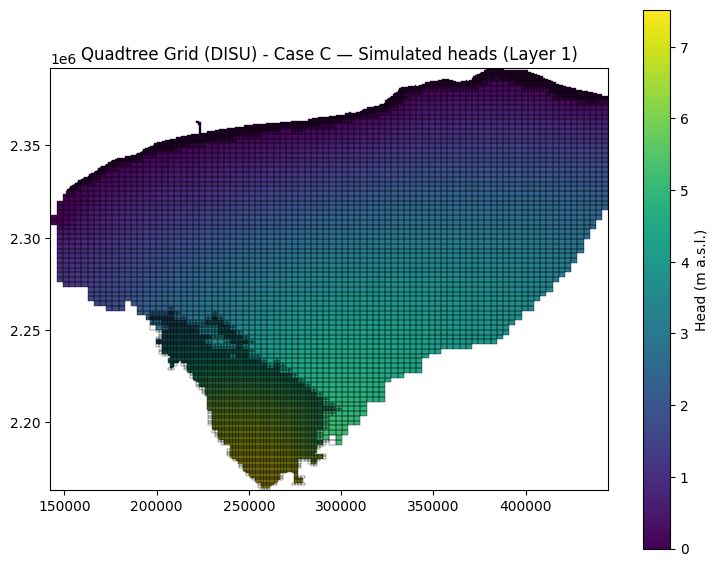

Budget record names: [b'    FLOW-JA-FACE', b'      DATA-SPDIS', b'             WEL', b'             RCH', b'             EVT', b'             CHD']


In [79]:
# Heads (steady-state → one output)
hobj = gwf.output.head()
h = hobj.get_data(kstpkper=(0,0))           #shape: (nlay, nrow, ncol)

plt.figure(figsize=(9,7))
pmv = flopy.plot.PlotMapView(modelgrid=gwf.modelgrid, layer=0)
pc  = pmv.plot_array(h[0][0])   
pmv.plot_grid(lw=0.25, color='k')
plt.colorbar(pc,label="Head (m a.s.l.)")
plt.title("Quadtree Grid (DISU) - Case C — Simulated heads (Layer 1)")
plt.gca().set_aspect('equal'); plt.show()

# Budget summary
bud = gwf.output.budget()
# MF6 prints a summary in console via OC; here’s a quick check of net imbalance:
from flopy.utils.utils_def import totim_to_datetime
# total IN and OUT from budget text (optional: parse bud file)
recnames = bud.get_unique_record_names()
print("Budget record names:", recnames)

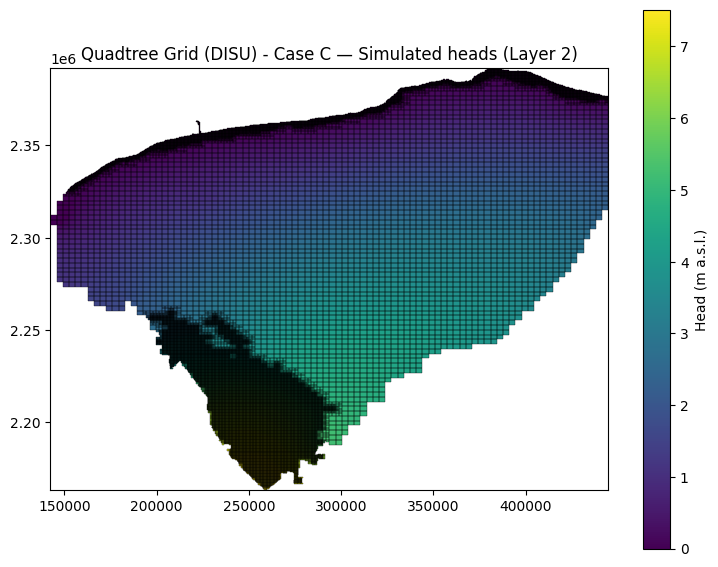

Budget record names: [b'    FLOW-JA-FACE', b'      DATA-SPDIS', b'             WEL', b'             RCH', b'             EVT', b'             CHD']


In [80]:
# Heads (steady-state → one output)
hobj = gwf.output.head()
h = hobj.get_data(kstpkper=(0,0))           #shape: (nlay, nrow, ncol)

plt.figure(figsize=(9,7))
pmv = flopy.plot.PlotMapView(modelgrid=gwf.modelgrid, layer=1)
pc  = pmv.plot_array(h[0][0])   
pmv.plot_grid(lw=0.25, color='k')
plt.colorbar(pc,label="Head (m a.s.l.)")
plt.title("Quadtree Grid (DISU) - Case C — Simulated heads (Layer 2)")
plt.gca().set_aspect('equal'); plt.show()

# Budget summary
bud = gwf.output.budget()
# MF6 prints a summary in console via OC; here’s a quick check of net imbalance:
# total IN and OUT from budget text (optional: parse bud file)
recnames = bud.get_unique_record_names()
print("Budget record names:", recnames)

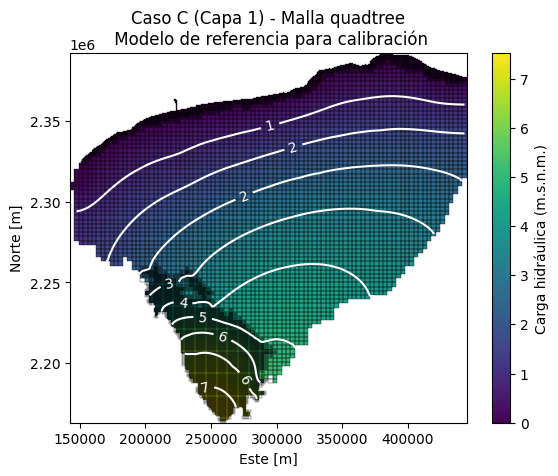

In [81]:

fig, ax = plt.subplots()
modelMap = flopy.plot.PlotMapView(modelgrid=gwf.modelgrid,ax=ax,layer=0)
modelMap.plot_grid(lw=0.25, color='k')
hd = modelMap.plot_array(h[0][0],ax=ax,alpha=1.0,cmap='viridis')
contour = modelMap.contour_array(h[0][0],ax=ax,levels=10,colors='white')
plt.colorbar(hd, label="Carga hidráulica (m.s.n.m.)")
labels = plt.clabel(contour,fmt="%1.0f")

cbc = flopy.utils.CellBudgetFile("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\yucatan_modelC\\quadtreeGrid\\gridgen_disu\\quadtree_caseC.cbc", precision="double")
spdis = cbc.get_data(text="DATA-SPDIS")[0]
qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, gwf)

plt.xlabel('Este [m]')
plt.ylabel('Norte [m]')
plt.title('Caso C (Capa 1) - Malla quadtree\n Modelo de referencia para calibración')
plt.show()

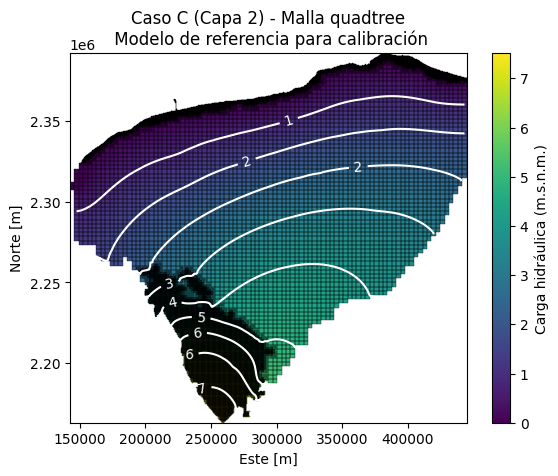

In [82]:
fig, ax = plt.subplots()
modelMap = flopy.plot.PlotMapView(modelgrid=gwf.modelgrid,ax=ax,layer=1)
hd = modelMap.plot_array(h[0][0],ax=ax,alpha=1.0, cmap='viridis')
modelMap.plot_grid(lw=0.25, color='k')
contour = modelMap.contour_array(h[0][0],ax=ax,levels=10, colors='white',
                               )
plt.colorbar(hd, label="Carga hidráulica (m.s.n.m.)")
labels = plt.clabel(contour,fmt="%1.0f")

cbc = flopy.utils.CellBudgetFile("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\yucatan_modelC\\quadtreeGrid\\gridgen_disu\\quadtree_caseC.cbc", precision="double")
spdis = cbc.get_data(text="DATA-SPDIS")[0]
qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, gwf)
plt.xlabel('Este [m]')
plt.ylabel('Norte [m]')
plt.title('Caso C (Capa 2) - Malla quadtree\n Modelo de referencia para calibración')
plt.show()

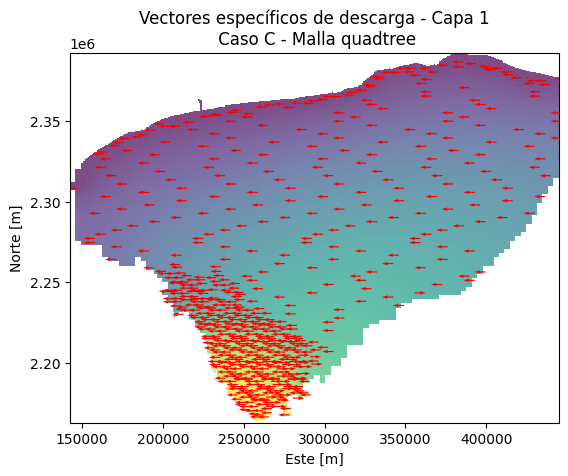

In [83]:
# Mask inactive cells in layer 1
qx0 = qx[0].copy(); qy0 = qy[0].copy()

# Optional: background heads for layer 1
#from flopy.utils import HeadFile
hds = flopy.utils.HeadFile("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\yucatan_modelC\\quadtreeGrid\\gridgen_disu\\quadtree_caseC.hds", precision="double")
# h = hds.get_data(kstpkper=(0,0))  # steady-state
# h0 = h[0]; 

pmv = flopy.plot.PlotMapView(model=gwf, layer=0)
pmv.plot_array(h, alpha=0.7)
# stride the arrows so you can actually see patterns
pmv.plot_vector(qx[idx_l1], qy[idx_l1], istep=20, jstep=20,normalize=True, color='red')
#pmv.plot_bc("CHD")  # nice sanity overlay
plt.xlabel('Este [m]')
plt.ylabel('Norte [m]')
plt.title('Vectores específicos de descarga - Capa 1\n Caso C - Malla quadtree')
plt.show()

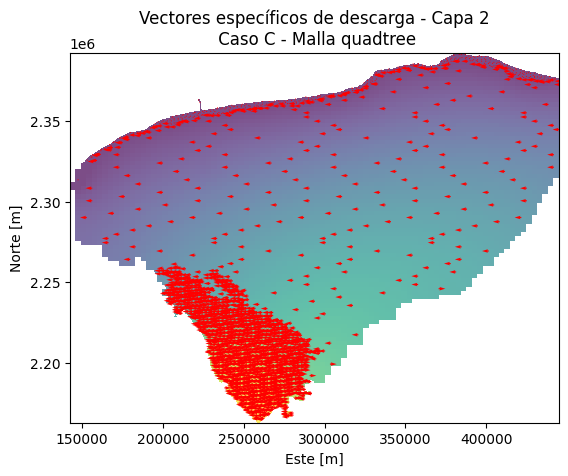

In [84]:
# Mask inactive cells in layer 1
qx0 = qx[1].copy(); qy0 = qy[1].copy()

# Optional: background heads for layer 1
#from flopy.utils import HeadFile
hds = flopy.utils.HeadFile("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\yucatan_modelC\\quadtreeGrid\\gridgen_disu\\quadtree_caseC.hds", precision="double")
# h = hds.get_data(kstpkper=(0,0))  # steady-state
# h0 = h[0]; 

pmv = flopy.plot.PlotMapView(model=gwf, layer=1)
pmv.plot_array(h, alpha=0.7)
# stride the arrows so you can actually see patterns
pmv.plot_vector(qx[idx_l2], qy[idx_l2], istep=20, jstep=20,normalize=True, color='red')
#pmv.plot_bc("CHD")  # nice sanity overlay
plt.xlabel('Este [m]')
plt.ylabel('Norte [m]')
plt.title('Vectores específicos de descarga - Capa 2\n Caso C - Malla quadtree')
plt.show()

In [85]:
# # Sum over layers (units remain [L/T]): this is the vertically-integrated specific discharge
# qx2d = np.nansum(qx, axis=0)
# qy2d = np.nansum(qy, axis=0)

# # Mask with top layer idomain
# qx2d[mask0] = np.nan
# qy2d[mask0] = np.nan

# pmv = flopy.plot.PlotMapView(model=gwf)
# pmv.plot_vector(qx2d, qy2d, istep=20, jstep=20, normalize=False, color='red')  # magnitudes visible
# plt.title("Depth-integrated specific discharge vectors")
# plt.show()


In [86]:
df = pd.read_csv("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\piezometric_median_2010_2024.csv") # piezometric heads values
print(df)

                       obs_id        lon        lat            x            y  \
0    1 C  Predio don Tiburcio -89.283056  21.169444  262946.8324  2342606.856   
1                1A  Sn. Juan -89.270278  21.300278  264482.1524  2357076.403   
2        1A.- PLANTEL SN JUAN -89.264056  21.304293  265134.2561  2357511.741   
3       1B  Hcda. San Eduardo -89.282778  21.228889  263070.6029  2349189.419   
4            1B.- SAN EDUARDO -89.275975  21.233134  263783.7281  2349649.333   
..                        ...        ...        ...          ...          ...   
158               RM12CHEUMAN -89.706180  21.067303  218798.1289  2331984.650   
159             RM13TIXCUYTUN -89.570256  21.066222  232927.4588  2331630.856   
160              RM14MEGALITA -89.518667  21.099444  238348.8424  2335224.646   
161        RM15SIERRA PAPACAL -89.727417  21.123090  216696.0836  2338201.703   
162            RM18 SAC NICTE -89.584114  21.142072  231623.2825  2340055.166   

     n_measurements  head_o

In [87]:
df = df[df["n_measurements"] >= 3]
df

,obs_id,lon,lat,x,y,n_measurements,head_obs,weight
2,1A.- PLANTEL SN JUAN,-89.264056,21.304293,265134.2561,2357511.741,13,0.250,0.866667
4,1B.- SAN EDUARDO,-89.275975,21.233134,263783.7281,2349649.333,14,0.515,0.933333
5,1C.- QUINTA ROSARIO,-89.276598,21.173358,263623.8627,2343030.648,14,0.740,0.933333
7,2A.- DZILAM BRAVO,-88.900445,21.349198,302925.3018,2361985.296,15,0.270,1.000000
9,2B.- DZILAM GLEZ,-88.923179,21.294095,300492.6609,2355912.776,15,0.990,1.000000
...,...,...,...,...,...,...,...,...
158,RM12CHEUMAN,-89.706180,21.067303,218798.1289,2331984.650,11,1.330,0.733333
159,RM13TIXCUYTUN,-89.570256,21.066222,232927.4588,2331630.856,9,1.420,0.600000
160,RM14MEGALITA,-89.518667,21.099444,238348.8424,2335224.646,10,1.320,0.666667
161,RM15SIERRA PAPACAL,-89.727417,21.123090,216696.0836,2338201.703,10,0.675,0.666667


In [88]:
## Mapping of each well to it model cell (row,col) so we can:


ij = [gwf.modelgrid.intersect(x,y) for x,y in zip(df.x,df.y)] ## mg.intersect: returns (row,col) of the cell that contains the X,Y point
                                                          ## returns None if the points is outside the grid extent   


#wells = np.zeros_like(yucatanRaster_unstructured, dtype=int)

# Keep only indices that fall inside the raster bounds (safety)
# nrow, ncol = wells.shape
# ok = (rows >= 0) & (rows < nrow) & (cols >= 0) & (cols < ncol)

In [ ]:
ij_clean = [i for i in ij if i is not None]
print("Total wells:", len(ij_clean))
print("Unique node ids:", len(set(ij_clean)))
print("Duplicates:", len(ij_clean) - len(set(ij_clean)))

Total wells: 135
Unique node ids: 108
Duplicates: 27


In [ ]:
well_heads = h[0][0]
simulated_heads_values = []

for idx,id in enumerate(ij):
    simulated_heads_values.append(well_heads[id])

simulated_heads_values = np.array(simulated_heads_values)
simulated_heads_values.shape

(135,)

In [ ]:
cal_df = pd.DataFrame()
cal_df["pozo"] = df.obs_id
cal_df["observed_median_head"] = df.head_obs
cal_df["simulated_median_head"] = simulated_heads_values
cal_df = cal_df.dropna(subset=["observed_median_head"])
cal_df

,pozo,observed_median_head,simulated_median_head
2,1A.- PLANTEL SN JUAN,0.250,0.099645
4,1B.- SAN EDUARDO,0.515,0.400747
5,1C.- QUINTA ROSARIO,0.740,0.753018
7,2A.- DZILAM BRAVO,0.270,0.120862
9,2B.- DZILAM GLEZ,0.990,0.467957
...,...,...,...
158,RM12CHEUMAN,1.330,0.674984
159,RM13TIXCUYTUN,1.420,0.811030
160,RM14MEGALITA,1.320,0.800874
161,RM15SIERRA PAPACAL,0.675,0.407535


In [ ]:
residual = simulated_heads_values - df.head_obs
r = residual[~np.isnan(residual)] ## drop NaNs values from residual array 

abs_r = r.abs()

## METRICS
rmse = np.sqrt(np.mean(r**2))
mean_error = np.mean(r) #bias (signed)
max_abs_error = np.max(np.abs(r))    #worst mismatch

print(f"RMSE: {rmse:.3f} m")
print(f"Mean error (bias): {mean_error:.3f} m")
print(f"Max |error|: {max_abs_error:.3f} m")

RMSE: 0.888 m
Mean error (bias): -0.047 m
Max |error|: 4.252 m


In [ ]:
mae = np.mean(np.abs(r))
median_abs = np.median(np.abs(r))

print(f"MAE: {mae:.3f} m")
print(f"Median |error|: {median_abs:.3f} m")

MAE: 0.574 m
Median |error|: 0.343 m
